# Final model analysis — comprehensive report material generator

Loads the final resume2 checkpoint and produces every piece of analysis material needed for the project report:

1. **Confusion matrices at multiple thresholds** (0.05, 0.10, 0.25, 0.50) — shows real model behavior vs the conservative 0.25 default
2. **Per-class precision-recall curves** — one plot per class with AP annotated
3. **Per-class AP at multiple IoU thresholds** (0.50, 0.75, 0.50-0.95)
4. **Size-based AP breakdown** (small/medium/large objects)
5. **Prediction score distribution histogram** — explains the conservative-confidence pattern
6. **Qualitative prediction visualizations** on 8 validation images
7. **Full training trajectory plot** (all 27 epochs from 3 runs)

Does NOT train. Read-only analysis on the final locked checkpoint.

**Input:** `a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt` under `anonymized-checkpoints`

**Output:** All figures, CSVs, and images saved to `/kaggle/working/analysis_output/` and zipped for download.


In [5]:
%pip install -q transformers accelerate timm pycocotools iterative-stratification torchmetrics scipy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import json
import math
import os
import random
import shutil
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFile
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import MultiLabelBinarizer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import Dinov2Model, RTDetrForObjectDetection, RTDetrImageProcessor

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)


DEVICE: cuda


## Configuration

In [7]:

POSSIBLE_ROOTS = [
    Path("/kaggle/input/anonymized-dataset"),
    Path("/kaggle/input/datasets/anonymous-user/anonymized-dataset"),
]

DATASET_ROOT = None
for p in POSSIBLE_ROOTS:
    if p.exists():
        DATASET_ROOT = p
        break
if DATASET_ROOT is None:
    raise FileNotFoundError("Could not find anonymized-dataset under /kaggle/input.")

IMAGES_DIR = DATASET_ROOT / "train"
ANNOTATIONS_PATH = DATASET_ROOT / "train" / "_annotations.coco.json"

CKPT_ROOT_CANDIDATES = [
    Path("/kaggle/input/anonymized-checkpoints"),
    Path("/kaggle/input/datasets/anonymous-user/anonymized-checkpoints"),
]
CKPT_ROOT = None
for p in CKPT_ROOT_CANDIDATES:
    if p.exists():
        CKPT_ROOT = p
        break
if CKPT_ROOT is None:
    raise FileNotFoundError("Could not find anonymized-checkpoints under /kaggle/input.")

WORK_DIR = Path("/kaggle/working")
PROJECT_ROOT = WORK_DIR / "analysis_output"
META_DIR = PROJECT_ROOT / "meta"
RUN_DIR = PROJECT_ROOT / "runs"
BUNDLE_DIR = PROJECT_ROOT / "bundle"
PLOT_DIR = PROJECT_ROOT / "plots"

for p in [META_DIR, RUN_DIR, BUNDLE_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

KEEP_CLASS_TARGETS = [
    "bone level resorption",
    "dental crown",
    "dental filling",
    "dental implant",
    "mandibular nerve",
    "maxillary sinus",
    "periodental infection",
    "periodontal infection",
    "root canal traitement",
    "tooth decay",
    "wisdom tooth",
]

DROP_CLASS_TARGETS = [
    "dental impaction",
    "orthodontic traitement",
    "temporary tooth",
    "absent tooth",
    "tooth with unfavorable prognosis",
]

DINO_CHECKPOINT = "facebook/dinov2-small"
RTDETR_CHECKPOINT = "PekingU/rtdetr_r50vd"

# 5-hour Kaggle-T4 resume defaults
IMAGE_SIZE = 672
BATCH_SIZE = 2
ACCUM_STEPS = 4
NUM_WORKERS = 0
NUM_EPOCHS = 8
VAL_SIZE = 0.15

LR = 1e-5
BACKBONE_LR = 1e-6
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 1
MIN_LR_RATIO = 0.15
MAX_GRAD_NORM = 0.1
USE_AMP = True
ENABLE_GRADIENT_CHECKPOINTING = True

MASK_LOSS_WEIGHT = 1.0
MASK_SIZE = 56

# Validation / reporting thresholds
PRED_SCORE_THRESHOLD = 0.05
CONFUSION_SCORE_THRESHOLD = 0.25
BOX_CONFUSION_IOU = 0.50
MASK_CONFUSION_IOU = 0.50

SANITY_STEPS = 0

# DETR-style Hungarian mask matching costs
MATCH_COST_CLASS = 2.0
MATCH_COST_BBOX = 5.0
MATCH_COST_GIOU = 2.0

# Imbalance-aware weighting
CLASS_WEIGHT_POWER = 0.5
SAMPLER_WEIGHT_POWER = 0.5
CLASS_WEIGHT_CLIP_MAX = 3.0

USE_LORA = False
UNFREEZE_START_BLOCK = 8

# Data augmentation (unchanged)
AUG_HFLIP_PROB = 0.5
AUG_BRIGHTNESS = 0.15
AUG_CONTRAST = 0.15
AUG_ROTATION_DEG = 5.0

# Keep trainable footprint compact (unchanged)
TRAINABLE_DETECTOR_PATTERNS = [
    ".decoder.",
    "decoder.",
    "class_embed",
    "bbox_embed",
    "enc_score_head",
    "enc_bbox_head",
    "query_pos_head",
    "query_position_head",
    "input_proj",
    "decoder_input_proj",
    "memory_trans_fc",
    "memory_trans_norm",
]

RUN_TAG = "final_analysis"

PRIMARY_SELECTION_RULE = "combined_map = 0.5 * box_map + 0.5 * mask_map"
EARLY_STOP_METRIC = "combined_map"
EARLY_STOP_PATIENCE = 6
EARLY_STOP_MIN_DELTA = 0.001
MIN_EPOCHS_BEFORE_EARLY_STOP = 4

SAVE_EVERY_N_EPOCHS = 1
FULL_EVAL_EVERY_N_EPOCHS = 4
FULL_EVAL_ALWAYS_AT_FINAL = True
MASK_GATE_SAVE_JSON = False
SKIP_FULL_MASK_GATE = True

RESUME_PREFERENCE = "best_box50"  # alternatives: best_box50, best_box, best_mask, best_mask50

def find_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

resume_candidates_by_pref = {
    "best_combined": [
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_resume2_5h_best_combined_map.pt",
    ],
    "best_box50": [
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt",
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_best_box_map50.pt",
    ],
    "best_box": [
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_resume2_5h_best_box_map.pt",
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_best_box_map.pt",
    ],
    "best_mask": [
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_resume2_5h_best_mask_map.pt",
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_best_mask_map.pt",
    ],
    "best_mask50": [
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_resume2_5h_best_mask_map50.pt",
        CKPT_ROOT / "a4_plain56_multiscale_t4safe_best_mask_map50.pt",
    ],
}

RESUME_CKPT = find_first_existing(resume_candidates_by_pref.get(RESUME_PREFERENCE, []))
if RESUME_CKPT is None:
    # broad fallback search
    fallback_pool = []
    for pref in ["best_combined", "best_box50", "best_box", "best_mask50", "best_mask"]:
        fallback_pool.extend(resume_candidates_by_pref[pref])
    RESUME_CKPT = find_first_existing(fallback_pool)
if RESUME_CKPT is None:
    raise FileNotFoundError("Could not find a saved plain56 checkpoint under anonymized-checkpoints.")

SPLIT_TRAIN_CSV = CKPT_ROOT / "train_images.csv"
SPLIT_VAL_CSV = CKPT_ROOT / "val_images.csv"

print("DATASET_ROOT:", DATASET_ROOT)
print("CKPT_ROOT:", CKPT_ROOT)
print("RESUME_CKPT:", RESUME_CKPT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DINO_CHECKPOINT:", DINO_CHECKPOINT)
print("RTDETR_CHECKPOINT:", RTDETR_CHECKPOINT)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE, "| ACCUM_STEPS:", ACCUM_STEPS, "| effective batch:", BATCH_SIZE * ACCUM_STEPS)
print("LoRA:", USE_LORA, "| Unfreeze from block:", UNFREEZE_START_BLOCK, "| Mask size:", MASK_SIZE)
print("Full eval cadence: every", FULL_EVAL_EVERY_N_EPOCHS, "epochs; final forced =", FULL_EVAL_ALWAYS_AT_FINAL)
print("Selection rule:", PRIMARY_SELECTION_RULE)
print("Early stopping:", EARLY_STOP_METRIC, "patience=", EARLY_STOP_PATIENCE, "min_delta=", EARLY_STOP_MIN_DELTA)


DATASET_ROOT: /kaggle/input/datasets/anonymous-user/anonymized-dataset
CKPT_ROOT: /kaggle/input/datasets/anonymous-user/anonymized-checkpoints
RESUME_CKPT: /kaggle/input/datasets/anonymous-user/anonymized-checkpoints/a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt
PROJECT_ROOT: /kaggle/working/analysis_output
DINO_CHECKPOINT: facebook/dinov2-small
RTDETR_CHECKPOINT: PekingU/rtdetr_r50vd
IMAGE_SIZE: 672
BATCH_SIZE: 2 | ACCUM_STEPS: 4 | effective batch: 8
LoRA: False | Unfreeze from block: 8 | Mask size: 56
Full eval cadence: every 4 epochs; final forced = True
Selection rule: combined_map = 0.5 * box_map + 0.5 * mask_map
Early stopping: combined_map patience= 6 min_delta= 0.001


## Load COCO, build the reduced polygon-aware benchmark, and compute class stats

In [8]:
with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as f:
    coco = json.load(f)

images_df = pd.DataFrame(coco["images"]).rename(columns={"id": "image_id"}).copy()
ann_df = pd.DataFrame(coco["annotations"]).rename(columns={"id": "annotation_id"}).copy()
cat_df = pd.DataFrame(coco["categories"]).rename(columns={"id": "category_id", "name": "category_name"}).copy()

def norm_name(x):
    x = str(x).strip().lower()
    x = x.replace("_", " ").replace("-", " ")
    x = " ".join(x.split())
    return x

cat_df["category_name_norm"] = cat_df["category_name"].apply(norm_name)
keep_targets = {norm_name(x) for x in KEEP_CLASS_TARGETS}

selected_cat_df = cat_df.loc[cat_df["category_name_norm"].isin(keep_targets)].copy()
selected_category_ids = sorted(selected_cat_df["category_id"].astype(int).tolist())

def resolve_image_path(file_name):
    file_name = str(file_name)
    candidates = [
        DATASET_ROOT / file_name,
        IMAGES_DIR / file_name,
        IMAGES_DIR / Path(file_name).name,
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[-1]

images_df["image_path"] = images_df["file_name"].apply(resolve_image_path)
images_df["file_exists"] = images_df["image_path"].apply(lambda p: Path(p).exists())

bbox_df = pd.DataFrame(
    ann_df["bbox"].apply(lambda b: b if isinstance(b, list) and len(b) == 4 else [np.nan] * 4).tolist(),
    columns=["x", "y", "w", "h"],
)
for c in ["x", "y", "w", "h"]:
    bbox_df[c] = pd.to_numeric(bbox_df[c], errors="coerce")
ann_df = pd.concat([ann_df, bbox_df], axis=1)

for c in ["annotation_id", "image_id", "category_id", "area"]:
    if c in ann_df.columns:
        ann_df[c] = pd.to_numeric(ann_df[c], errors="coerce")
for c in ["width", "height"]:
    if c in images_df.columns:
        images_df[c] = pd.to_numeric(images_df[c], errors="coerce")

ann_df = ann_df.merge(
    images_df[["image_id", "width", "height", "image_path", "file_exists", "file_name"]],
    on="image_id",
    how="left",
)
ann_df = ann_df.merge(
    cat_df[["category_id", "category_name", "category_name_norm"]],
    on="category_id",
    how="left",
)

ann_df = ann_df.loc[ann_df["file_exists"] == True].copy()
ann_df = ann_df.loc[ann_df["category_id"].isin(selected_category_ids)].copy()

def polygon_area_xy(points):
    if len(points) < 6:
        return 0.0
    xs = np.array(points[0::2], dtype=float)
    ys = np.array(points[1::2], dtype=float)
    return 0.5 * abs(np.dot(xs, np.roll(ys, -1)) - np.dot(ys, np.roll(xs, -1)))

def choose_best_polygon(segmentation):
    if not isinstance(segmentation, list) or len(segmentation) == 0:
        return None
    cands = []
    for poly in segmentation:
        if not isinstance(poly, list):
            continue
        if len(poly) < 6 or len(poly) % 2 != 0:
            continue
        area = polygon_area_xy(poly)
        if area > 0:
            cands.append((area, poly))
    if len(cands) == 0:
        return None
    cands.sort(key=lambda x: x[0], reverse=True)
    return cands[0][1]

ann_df["best_polygon"] = ann_df["segmentation"].apply(choose_best_polygon)
ann_df = ann_df.loc[ann_df["best_polygon"].notna()].copy()

ann_df["x"] = ann_df["x"].clip(lower=0)
ann_df["y"] = ann_df["y"].clip(lower=0)
ann_df["x2"] = (ann_df["x"] + ann_df["w"]).clip(upper=ann_df["width"])
ann_df["y2"] = (ann_df["y"] + ann_df["h"]).clip(upper=ann_df["height"])
ann_df["w"] = ann_df["x2"] - ann_df["x"]
ann_df["h"] = ann_df["y2"] - ann_df["y"]

ann_df = ann_df.loc[
    ann_df["x"].notna() & ann_df["y"].notna() &
    ann_df["w"].notna() & ann_df["h"].notna() &
    (ann_df["w"] > 0) & (ann_df["h"] > 0) &
    (ann_df["width"] > 0) & (ann_df["height"] > 0)
].copy()

present_category_ids = sorted(ann_df["category_id"].dropna().astype(int).unique().tolist())
present_cat_df = (
    selected_cat_df.loc[selected_cat_df["category_id"].isin(present_category_ids)]
    .copy().sort_values("category_id").reset_index(drop=True)
)

category_id_to_new = {cid: i for i, cid in enumerate(present_cat_df["category_id"].tolist())}
new_to_name = {i: name for i, name in enumerate(present_cat_df["category_name"].tolist())}
ann_df["class_id"] = ann_df["category_id"].map(category_id_to_new)

def build_class_stats(images_ref_df, anns_ref_df, prefix):
    ann_counts = anns_ref_df.groupby("class_id").size()
    image_counts = anns_ref_df.groupby("class_id")["image_id"].nunique()
    out = pd.DataFrame({
        "class_id": list(new_to_name.keys()),
        "class_name": [new_to_name[i] for i in new_to_name.keys()],
    })
    out[f"{prefix}_annotations"] = out["class_id"].map(ann_counts).fillna(0).astype(int)
    out[f"{prefix}_images"] = out["class_id"].map(image_counts).fillna(0).astype(int)
    return out

overall_class_stats = build_class_stats(images_df, ann_df, "overall")
overall_class_stats["overall_ann_pct"] = overall_class_stats["overall_annotations"] / max(1, overall_class_stats["overall_annotations"].sum())
overall_class_stats["overall_img_pct"] = overall_class_stats["overall_images"] / max(1, overall_class_stats["overall_images"].sum())
overall_class_stats.to_csv(META_DIR / "overall_class_stats.csv", index=False)

print("Reduced classes:")
display(present_cat_df[["category_id", "category_name"]])
display(overall_class_stats)

Reduced classes:


,category_id,category_name
0,2,Bone level resorption
1,3,Dental crown
2,4,Dental filling
3,6,Dental implant
4,7,Mandibular nerve
5,8,Maxillary sinus
6,10,Periodental infection
7,11,Root canal traitement
8,13,Tooth decay
9,15,Wisdom tooth


,class_id,class_name,overall_annotations,overall_images,overall_ann_pct,overall_img_pct
0,0,Bone level resorption,2672,1292,0.029808,0.047432
1,1,Dental crown,7977,2866,0.088990,0.105217
2,2,Dental filling,33516,6785,0.373900,0.249091
3,3,Dental implant,1353,443,0.015094,0.016263
4,4,Mandibular nerve,507,262,0.005656,0.009619
5,5,Maxillary sinus,399,201,0.004451,0.007379
6,6,Periodental infection,3607,1698,0.040239,0.062337
7,7,Root canal traitement,13179,3830,0.147023,0.140607
8,8,Tooth decay,7499,2205,0.083658,0.080950
9,9,Wisdom tooth,18930,7657,0.211180,0.281104


## Create a fixed train/val split, recover class imbalance stats, and build a class-aware sampler

In [9]:

img_to_classes = ann_df.groupby("image_id")["class_id"].apply(lambda s: sorted(set(int(v) for v in s.tolist()))).to_dict()

split_images_df = images_df.loc[images_df["file_exists"]].copy()
split_images_df["labels"] = split_images_df["image_id"].map(img_to_classes)
split_images_df["labels"] = split_images_df["labels"].apply(lambda x: x if isinstance(x, list) else [])
split_images_df = split_images_df.loc[split_images_df["labels"].apply(len) > 0].copy().reset_index(drop=True)

# Prefer the exact saved split from the previous run if available.
if SPLIT_TRAIN_CSV.exists() and SPLIT_VAL_CSV.exists():
    print("Using saved train/val split CSVs from:", CKPT_ROOT)
    saved_train_images = pd.read_csv(SPLIT_TRAIN_CSV)
    saved_val_images = pd.read_csv(SPLIT_VAL_CSV)

    train_image_ids = set(pd.to_numeric(saved_train_images["image_id"], errors="coerce").dropna().astype(int).tolist())
    val_image_ids = set(pd.to_numeric(saved_val_images["image_id"], errors="coerce").dropna().astype(int).tolist())

    train_images_df = split_images_df.loc[split_images_df["image_id"].isin(train_image_ids)].copy().reset_index(drop=True)
    val_images_df = split_images_df.loc[split_images_df["image_id"].isin(val_image_ids)].copy().reset_index(drop=True)

    # Safety fallback if the saved CSVs do not line up with the current reduced benchmark.
    if len(train_images_df) == 0 or len(val_images_df) == 0:
        print("Saved split CSVs did not match the current reduced benchmark cleanly. Falling back to a fresh stratified split.")
        mlb = MultiLabelBinarizer(classes=list(range(len(present_cat_df))))
        Y = mlb.fit_transform(split_images_df["labels"])
        msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
        train_idx, val_idx = next(msss.split(split_images_df, Y))
        train_images_df = split_images_df.iloc[train_idx].copy().reset_index(drop=True)
        val_images_df = split_images_df.iloc[val_idx].copy().reset_index(drop=True)
        train_image_ids = set(train_images_df["image_id"].tolist())
        val_image_ids = set(val_images_df["image_id"].tolist())
else:
    print("Saved split CSVs not found. Building a fresh multilabel stratified split.")
    mlb = MultiLabelBinarizer(classes=list(range(len(present_cat_df))))
    Y = mlb.fit_transform(split_images_df["labels"])
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
    train_idx, val_idx = next(msss.split(split_images_df, Y))
    train_images_df = split_images_df.iloc[train_idx].copy().reset_index(drop=True)
    val_images_df = split_images_df.iloc[val_idx].copy().reset_index(drop=True)
    train_image_ids = set(train_images_df["image_id"].tolist())
    val_image_ids = set(val_images_df["image_id"].tolist())

train_ann_df = ann_df.loc[ann_df["image_id"].isin(train_image_ids)].copy()
val_ann_df = ann_df.loc[ann_df["image_id"].isin(val_image_ids)].copy()

train_images_df.to_csv(META_DIR / "train_images.csv", index=False)
val_images_df.to_csv(META_DIR / "val_images.csv", index=False)
train_ann_df.to_csv(META_DIR / "train_annotations.csv", index=False)
val_ann_df.to_csv(META_DIR / "val_annotations.csv", index=False)

train_class_stats = build_class_stats(train_images_df, train_ann_df, "train")
val_class_stats = build_class_stats(val_images_df, val_ann_df, "val")

class_stats_df = overall_class_stats.merge(train_class_stats, on=["class_id", "class_name"]).merge(val_class_stats, on=["class_id", "class_name"])
class_stats_df["ann_imbalance_vs_max"] = class_stats_df["train_annotations"].max() / class_stats_df["train_annotations"].clip(lower=1)
class_stats_df["img_imbalance_vs_max"] = class_stats_df["train_images"].max() / class_stats_df["train_images"].clip(lower=1)

raw_class_weights = class_stats_df["train_annotations"].max() / class_stats_df["train_annotations"].clip(lower=1)
raw_class_weights = raw_class_weights.pow(CLASS_WEIGHT_POWER).clip(upper=CLASS_WEIGHT_CLIP_MAX)
class_stats_df["mask_class_weight_raw"] = raw_class_weights
class_stats_df["mask_class_weight"] = class_stats_df["mask_class_weight_raw"] / class_stats_df["mask_class_weight_raw"].mean()

sampler_class_weights = class_stats_df["train_images"].max() / class_stats_df["train_images"].clip(lower=1)
sampler_class_weights = sampler_class_weights.pow(SAMPLER_WEIGHT_POWER).clip(upper=CLASS_WEIGHT_CLIP_MAX)
class_stats_df["sampler_class_weight_raw"] = sampler_class_weights
class_stats_df["sampler_class_weight"] = class_stats_df["sampler_class_weight_raw"] / class_stats_df["sampler_class_weight_raw"].mean()

class_stats_df.to_csv(META_DIR / "class_stats_train_val.csv", index=False)
display(class_stats_df)

CLASS_WEIGHT_TENSOR = torch.tensor(class_stats_df.sort_values("class_id")["mask_class_weight"].values, dtype=torch.float32)

image_to_weight = {}
class_weight_map = dict(zip(class_stats_df["class_id"].tolist(), class_stats_df["sampler_class_weight"].tolist()))
for _, row in train_images_df.iterrows():
    labels = row["labels"]
    if not labels:
        image_to_weight[int(row["image_id"])] = 1.0
    else:
        image_to_weight[int(row["image_id"])] = float(np.mean([class_weight_map[int(c)] for c in labels]))

train_sample_weights = train_images_df["image_id"].map(image_to_weight).astype(float).values
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(train_sample_weights),
    replacement=True,
)

print("Train images:", len(train_images_df), "| Val images:", len(val_images_df))


Using saved train/val split CSVs from: /kaggle/input/datasets/anonymous-user/anonymized-checkpoints


,class_id,class_name,overall_annotations,overall_images,overall_ann_pct,overall_img_pct,train_annotations,train_images,val_annotations,val_images,ann_imbalance_vs_max,img_imbalance_vs_max,mask_class_weight_raw,mask_class_weight,sampler_class_weight_raw,sampler_class_weight
0,0,Bone level resorption,2672,1292,0.029808,0.047432,2272,1098,400,194,12.533011,5.927140,3.000000,1.299266,2.434572,1.185710
1,1,Dental crown,7977,2866,0.088990,0.105217,6767,2436,1210,430,4.207921,2.671593,2.051322,0.888404,1.634501,0.796051
2,2,Dental filling,33516,6785,0.373900,0.249091,28475,5767,5041,1018,1.000000,1.128490,1.000000,0.433089,1.062304,0.517374
3,3,Dental implant,1353,443,0.015094,0.016263,1185,377,168,66,24.029536,17.262599,3.000000,1.299266,3.000000,1.461091
4,4,Mandibular nerve,507,262,0.005656,0.009619,432,223,75,39,65.914352,29.183857,3.000000,1.299266,3.000000,1.461091
5,5,Maxillary sinus,399,201,0.004451,0.007379,339,171,60,30,83.997050,38.058480,3.000000,1.299266,3.000000,1.461091
6,6,Periodental infection,3607,1698,0.040239,0.062337,3052,1443,555,255,9.329948,4.510049,3.000000,1.299266,2.123687,1.034300
7,7,Root canal traitement,13179,3830,0.147023,0.140607,11197,3255,1982,575,2.543092,1.999386,1.594707,0.690650,1.413996,0.688659
8,8,Tooth decay,7499,2205,0.083658,0.080950,6378,1874,1121,331,4.464566,3.472785,2.112952,0.915096,1.863541,0.907601
9,9,Wisdom tooth,18930,7657,0.211180,0.281104,16074,6508,2856,1149,1.771494,1.000000,1.330975,0.576430,1.000000,0.487030


Train images: 7985 | Val images: 1400


## Dataset + collate (boxes + full masks + 28x28 masks)

In [10]:
import torchvision.transforms.functional as TF

image_processor = RTDetrImageProcessor.from_pretrained(
    RTDETR_CHECKPOINT,
    size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
    do_resize=True,
)

def polygon_to_mask(poly, width, height):
    mask = Image.new("L", (int(width), int(height)), 0)
    pts = [(float(poly[i]), float(poly[i + 1])) for i in range(0, len(poly), 2)]
    draw = ImageDraw.Draw(mask)
    draw.polygon(pts, outline=1, fill=1)
    return np.array(mask, dtype=np.uint8)

def resize_mask_to_square(mask_arr, size=56):
    img = Image.fromarray((mask_arr * 255).astype(np.uint8))
    img = img.resize((size, size), Image.NEAREST)
    arr = (np.array(img) > 0).astype(np.float32)
    return arr

def rotate_polygon(poly, angle_deg, width, height):
    if poly is None or len(poly) < 6:
        return poly
    angle_rad = math.radians(angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    cx, cy = width / 2.0, height / 2.0
    out = []
    for i in range(0, len(poly), 2):
        x = float(poly[i]) - cx
        y = float(poly[i + 1]) - cy
        xr = x * cos_a - y * sin_a + cx
        yr = x * sin_a + y * cos_a + cy
        xr = min(max(xr, 0.0), width - 1.0)
        yr = min(max(yr, 0.0), height - 1.0)
        out.extend([xr, yr])
    return out

def polygon_to_box(poly, width, height):
    xs = np.array(poly[0::2], dtype=np.float32)
    ys = np.array(poly[1::2], dtype=np.float32)
    x1 = float(np.clip(xs.min(), 0, width - 1))
    y1 = float(np.clip(ys.min(), 0, height - 1))
    x2 = float(np.clip(xs.max(), 0, width - 1))
    y2 = float(np.clip(ys.max(), 0, height - 1))
    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)
    return x1, y1, w, h

class DentalAugmentation:
    def __init__(self, hflip_prob=0.5, brightness=0.15, contrast=0.15, rotation_deg=5.0):
        self.hflip_prob = hflip_prob
        self.brightness = brightness
        self.contrast = contrast
        self.rotation_deg = rotation_deg

    def __call__(self, image, annotations, width, height):
        anns = [dict(a) for a in annotations]

        if random.random() < self.hflip_prob:
            image = TF.hflip(image)
            for ann in anns:
                poly = ann.get("best_polygon")
                if poly is not None:
                    flipped = []
                    for j in range(0, len(poly), 2):
                        flipped.append(width - poly[j])
                        flipped.append(poly[j + 1])
                    ann["best_polygon"] = flipped
                ann["x"] = width - ann["x"] - ann["w"]

        if self.rotation_deg and self.rotation_deg > 0:
            angle = random.uniform(-self.rotation_deg, self.rotation_deg)
            image = TF.rotate(image, angle=angle, interpolation=TF.InterpolationMode.BILINEAR, fill=0)
            for ann in anns:
                poly = ann.get("best_polygon")
                if poly is not None:
                    rot_poly = rotate_polygon(poly, angle, width, height)
                    ann["best_polygon"] = rot_poly
                    ann["x"], ann["y"], ann["w"], ann["h"] = polygon_to_box(rot_poly, width, height)

        if self.brightness > 0:
            image = TF.adjust_brightness(image, 1.0 + random.uniform(-self.brightness, self.brightness))
        if self.contrast > 0:
            image = TF.adjust_contrast(image, 1.0 + random.uniform(-self.contrast, self.contrast))

        filtered = []
        for ann in anns:
            if ann["w"] > 1 and ann["h"] > 1 and ann.get("best_polygon") is not None:
                filtered.append(ann)
        return image, filtered

train_augmentation = DentalAugmentation(
    hflip_prob=AUG_HFLIP_PROB,
    brightness=AUG_BRIGHTNESS,
    contrast=AUG_CONTRAST,
    rotation_deg=AUG_ROTATION_DEG,
)

class ReducedCocoMaskDataset(Dataset):
    def __init__(self, images_df, ann_df, augmentation=None):
        self.images_df = images_df.reset_index(drop=True)
        self.augmentation = augmentation
        self.anns_grouped = defaultdict(list)
        for row in ann_df.itertuples(index=False):
            self.anns_grouped[int(row.image_id)].append(row)

    def __len__(self):
        return len(self.images_df)

    def __getitem__(self, idx):
        row = self.images_df.iloc[idx]
        image_id = int(row["image_id"])
        image = Image.open(row["image_path"]).convert("RGB")
        width, height = image.size

        raw_anns = []
        for ann in self.anns_grouped.get(image_id, []):
            raw_anns.append(
                {
                    "x": float(ann.x),
                    "y": float(ann.y),
                    "w": float(ann.w),
                    "h": float(ann.h),
                    "class_id": int(ann.class_id),
                    "best_polygon": list(ann.best_polygon),
                }
            )

        if self.augmentation is not None:
            image, anns_iter = self.augmentation(image, raw_anns, width, height)
        else:
            anns_iter = raw_anns

        annotations = []
        metric_boxes = []
        metric_labels = []
        gt_masks_small = []
        gt_masks_full = []

        for ann in anns_iter:
            annotations.append(
                {
                    "bbox": [float(ann["x"]), float(ann["y"]), float(ann["w"]), float(ann["h"])],
                    "category_id": int(ann["class_id"]),
                    "area": float(ann["w"] * ann["h"]),
                    "iscrowd": 0,
                }
            )

            metric_boxes.append([
                float(ann["x"]),
                float(ann["y"]),
                float(ann["x"] + ann["w"]),
                float(ann["y"] + ann["h"]),
            ])
            metric_labels.append(int(ann["class_id"]))

            full_mask = polygon_to_mask(ann["best_polygon"], width, height)
            gt_masks_full.append(full_mask.astype(np.uint8))
            gt_masks_small.append(resize_mask_to_square(full_mask, MASK_SIZE))

        metric_target = {
            "boxes": torch.tensor(metric_boxes, dtype=torch.float32) if len(metric_boxes) else torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.tensor(metric_labels, dtype=torch.int64) if len(metric_labels) else torch.zeros((0,), dtype=torch.int64),
            "masks": torch.tensor(np.stack(gt_masks_full), dtype=torch.uint8) if len(gt_masks_full) else torch.zeros((0, image.height, image.width), dtype=torch.uint8),
        }

        hf_annotations = {"image_id": image_id, "annotations": annotations}

        return {
            "image": image,
            "image_id": image_id,
            "image_path": str(row["image_path"]),
            "file_name": str(row["file_name"]) if "file_name" in row else Path(row["image_path"]).name,
            "hf_annotations": hf_annotations,
            "metric_target": metric_target,
            "orig_size": (image.height, image.width),
            "gt_masks_small": torch.tensor(np.stack(gt_masks_small), dtype=torch.float32) if len(gt_masks_small) else torch.zeros((0, MASK_SIZE, MASK_SIZE), dtype=torch.float32),
        }

def collate_fn(batch):
    images = [b["image"] for b in batch]
    hf_annotations = [b["hf_annotations"] for b in batch]
    metric_targets = [b["metric_target"] for b in batch]
    orig_sizes = torch.tensor([b["orig_size"] for b in batch], dtype=torch.int64)
    gt_masks_small = [b["gt_masks_small"] for b in batch]
    image_ids = [b["image_id"] for b in batch]
    image_paths = [b["image_path"] for b in batch]
    file_names = [b["file_name"] for b in batch]

    enc = image_processor(images=images, annotations=hf_annotations, return_tensors="pt")
    enc["metric_targets"] = metric_targets
    enc["orig_sizes"] = orig_sizes
    enc["gt_masks_small"] = gt_masks_small
    enc["image_ids"] = image_ids
    enc["image_paths"] = image_paths
    enc["file_names"] = file_names
    return enc

train_ds = ReducedCocoMaskDataset(train_images_df, train_ann_df, augmentation=train_augmentation)
val_ds = ReducedCocoMaskDataset(val_images_df, val_ann_df, augmentation=None)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print(batch["pixel_values"].shape)
print(batch["orig_sizes"].shape)
print(len(batch["labels"]), len(batch["metric_targets"]), len(batch["gt_masks_small"]))


preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

torch.Size([2, 3, 672, 672])
torch.Size([2, 2])
2 2 2


## Bug-fixed DINO bridge and corrected RT-DETR backbone contract

In [11]:
class LayerNorm2d(nn.Module):
    def __init__(self, num_channels, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=1, keepdim=True)
        x = (x - mean) / torch.sqrt(var + self.eps)
        return self.weight[:, None, None] * x + self.bias[:, None, None]

class DinoPyramidBridge(nn.Module):
    def __init__(self, in_channels=384):
        super().__init__()
        self.level1 = nn.Sequential(nn.Conv2d(in_channels, 512, 1), LayerNorm2d(512))
        self.level2 = nn.Sequential(
            nn.Conv2d(in_channels, 1024, 1),
            nn.Conv2d(1024, 1024, 3, stride=2, padding=1),
            LayerNorm2d(1024),
        )
        self.level3 = nn.Sequential(
            nn.Conv2d(in_channels, 2048, 1),
            nn.Conv2d(2048, 2048, 3, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(2048, 2048, 3, stride=2, padding=1),
            LayerNorm2d(2048),
        )

    def tokens_to_map(self, hidden_state):
        x = hidden_state[:, 1:, :]
        B, N, C = x.shape
        side = int(math.sqrt(N))
        assert side * side == N, f"Token count {N} not square"
        return x.transpose(1, 2).contiguous().view(B, C, side, side)

    def forward(self, hs_l1, hs_l2, hs_l3):
        f1 = self.tokens_to_map(hs_l1)
        f2 = self.tokens_to_map(hs_l2)
        f3 = self.tokens_to_map(hs_l3)

        p1 = self.level1(f1)
        p2 = self.level2(f2)
        p3 = self.level3(f3)

        h1, w1 = p1.shape[-2:]
        target_h2, target_w2 = h1 // 2, w1 // 2
        target_h3, target_w3 = h1 // 4, w1 // 4

        p2 = F.interpolate(p2, size=(target_h2, target_w2), mode="bilinear", align_corners=False)
        p3 = F.interpolate(p3, size=(target_h3, target_w3), mode="bilinear", align_corners=False)
        return [p1, p2, p3]

class DinoRtDetrBackboneAdapter(nn.Module):
    def __init__(self, dino_checkpoint=DINO_CHECKPOINT):
        super().__init__()
        self.dino = Dinov2Model.from_pretrained(dino_checkpoint)
        self.bridge = DinoPyramidBridge(in_channels=self.dino.config.hidden_size)
        self.last_feature_maps = None

    def _resize_mask(self, pixel_mask, feature_map):
        if pixel_mask is None:
            B, _, H, W = feature_map.shape
            return torch.zeros((B, H, W), dtype=torch.bool, device=feature_map.device)
        m = pixel_mask.float().unsqueeze(1)
        m = F.interpolate(m, size=feature_map.shape[-2:], mode="nearest")
        return (m[:, 0] > 0.5)

    def forward(self, pixel_values, pixel_mask=None):
        out = self.dino(
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True,
            interpolate_pos_encoding=True,
        )
        hs = out.hidden_states
        p1, p2, p3 = self.bridge(hs[4], hs[8], hs[12])
        self.last_feature_maps = [p1, p2, p3]

        m1 = self._resize_mask(pixel_mask, p1)
        m2 = self._resize_mask(pixel_mask, p2)
        m3 = self._resize_mask(pixel_mask, p3)

        return [(p1, m1), (p2, m2), (p3, m3)]

## A4 wrapper model: multi-scale 56×56 mask head + DETR-style Hungarian mask matching (no LoRA)

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        layers = []
        dims = [input_dim] + [hidden_dim] * (num_layers - 1) + [output_dim]
        for i in range(num_layers):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < num_layers - 1:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class QueryMaskHead(nn.Module):
    """Multi-scale mask head: fuse P1 (512c) + P2 (1024c), predict 56x56 masks."""
    def __init__(self, query_dim=256, p1_dim=512, p2_dim=1024, mask_dim=128, out_size=56):
        super().__init__()
        self.p1_proj = nn.Sequential(
            nn.Conv2d(p1_dim, mask_dim, kernel_size=1),
            nn.GroupNorm(8, mask_dim),
            nn.ReLU(),
        )
        self.p2_proj = nn.Sequential(
            nn.Conv2d(p2_dim, mask_dim, kernel_size=1),
            nn.GroupNorm(8, mask_dim),
            nn.ReLU(),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(mask_dim * 2, mask_dim, kernel_size=3, padding=1),
            nn.GroupNorm(8, mask_dim),
            nn.ReLU(),
        )
        self.query_to_mask = MLP(query_dim, query_dim, mask_dim, 3)
        self.out_size = out_size

    def forward(self, query_states, p1_feature, p2_feature):
        f1 = self.p1_proj(p1_feature)
        f2 = self.p2_proj(p2_feature)
        f2_up = F.interpolate(f2, size=f1.shape[-2:], mode="bilinear", align_corners=False)
        fused = self.fuse(torch.cat([f1, f2_up], dim=1))
        mask_embed = self.query_to_mask(query_states)
        mask_logits = torch.einsum("bqm,bmhw->bqhw", mask_embed, fused)
        mask_logits = F.interpolate(mask_logits, size=(self.out_size, self.out_size), mode="bilinear", align_corners=False)
        return mask_logits

def cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

def box_iou_xyxy(boxes1, boxes2):
    area1 = ((boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0))
    area2 = ((boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0))
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-6)

def generalized_box_iou(boxes1, boxes2):
    iou = box_iou_xyxy(boxes1, boxes2)
    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    area_c = wh[..., 0] * wh[..., 1]

    area1 = ((boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0))
    area2 = ((boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0))
    lt_int = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb_int = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh_int = (rb_int - lt_int).clamp(min=0)
    inter = wh_int[..., 0] * wh_int[..., 1]
    union = area1[:, None] + area2 - inter
    return iou - (area_c - union) / area_c.clamp(min=1e-6)

def dice_loss_from_logits(logits, targets):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(1, 2))
    den = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2)) + 1e-6
    return 1.0 - (num / den)

def _get_label_tensor(target):
    if "class_labels" in target:
        return target["class_labels"]
    if "labels" in target:
        return target["labels"]
    raise KeyError("Could not find class labels in target dict.")

@torch.no_grad()
def detr_style_hungarian_match_single(pred_logits, pred_boxes, target_labels):
    tgt_labels = _get_label_tensor(target_labels)
    tgt_boxes = target_labels["boxes"]

    if tgt_boxes.numel() == 0:
        return (
            torch.zeros((0,), dtype=torch.int64, device=pred_boxes.device),
            torch.zeros((0,), dtype=torch.int64, device=pred_boxes.device),
        )

    pred_prob = pred_logits.sigmoid()
    cost_class = 1.0 - pred_prob[:, tgt_labels]
    cost_bbox = torch.cdist(pred_boxes, tgt_boxes, p=1)
    pred_boxes_xyxy = cxcywh_to_xyxy(pred_boxes)
    tgt_boxes_xyxy = cxcywh_to_xyxy(tgt_boxes)
    cost_giou = 1.0 - generalized_box_iou(pred_boxes_xyxy, tgt_boxes_xyxy)

    total_cost = (
        MATCH_COST_CLASS * cost_class
        + MATCH_COST_BBOX * cost_bbox
        + MATCH_COST_GIOU * cost_giou
    )

    row_ind, col_ind = linear_sum_assignment(total_cost.detach().cpu().numpy())
    row_ind = torch.as_tensor(row_ind, dtype=torch.int64, device=pred_boxes.device)
    col_ind = torch.as_tensor(col_ind, dtype=torch.int64, device=pred_boxes.device)
    return row_ind, col_ind

def matched_mask_loss(pred_logits, pred_boxes, pred_masks, target_labels, gt_masks_small, class_weights=None):
    B, Q = pred_boxes.shape[:2]
    total_loss = pred_boxes.new_tensor(0.0)
    total_weight = pred_boxes.new_tensor(0.0)

    for b in range(B):
        tgt_boxes = target_labels[b]["boxes"]
        if tgt_boxes.numel() == 0:
            continue

        q_idx, t_idx = detr_style_hungarian_match_single(pred_logits[b], pred_boxes[b], target_labels[b])
        if q_idx.numel() == 0:
            continue

        pm = pred_masks[b, q_idx]
        gm = gt_masks_small[b][t_idx].to(pm.device)

        bce = F.binary_cross_entropy_with_logits(pm, gm, reduction="none").mean(dim=(1, 2))
        dsc = dice_loss_from_logits(pm, gm)
        per_match_loss = bce + dsc

        if class_weights is not None:
            tgt_cls = _get_label_tensor(target_labels[b])[t_idx]
            w = class_weights[tgt_cls].to(per_match_loss.device)
            per_match_loss = per_match_loss * w
            total_weight = total_weight + w.sum()
        else:
            total_weight = total_weight + per_match_loss.new_tensor(float(per_match_loss.numel()))

        total_loss = total_loss + per_match_loss.sum()

    if float(total_weight.item()) == 0.0:
        return pred_masks.sum() * 0.0
    return total_loss / total_weight.clamp(min=1e-6)

class DinoRtDetrA4(nn.Module):
    def __init__(self, num_labels, id2label, label2id):
        super().__init__()
        self.detector = RTDetrForObjectDetection.from_pretrained(
            RTDETR_CHECKPOINT,
            num_labels=num_labels,
            ignore_mismatched_sizes=True,
            id2label=id2label,
            label2id=label2id,
        )
        self.detector.model.backbone = DinoRtDetrBackboneAdapter()
        self.mask_head = QueryMaskHead(query_dim=256, p1_dim=512, p2_dim=1024, mask_dim=128, out_size=MASK_SIZE)

    def _get_query_states(self, outputs):
        if hasattr(outputs, "decoder_hidden_states") and outputs.decoder_hidden_states is not None:
            return outputs.decoder_hidden_states[-1]
        if hasattr(outputs, "intermediate_hidden_states") and outputs.intermediate_hidden_states is not None:
            return outputs.intermediate_hidden_states[-1]
        if hasattr(outputs, "decoder_last_hidden_state") and outputs.decoder_last_hidden_state is not None:
            return outputs.decoder_last_hidden_state
        raise RuntimeError("Could not find decoder/query hidden states in RT-DETR outputs.")

    def forward(self, pixel_values, pixel_mask=None, labels=None, gt_masks_small=None, class_weights=None):
        outputs = self.detector(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            labels=labels,
            output_hidden_states=True,
            return_dict=True,
        )

        query_states = self._get_query_states(outputs)
        p1_feature = self.detector.model.backbone.last_feature_maps[0]
        p2_feature = self.detector.model.backbone.last_feature_maps[1]
        pred_masks = self.mask_head(query_states, p1_feature, p2_feature)

        det_loss = outputs.loss if labels is not None else None
        mask_loss = None
        total_loss = det_loss

        if labels is not None and gt_masks_small is not None:
            mask_loss = matched_mask_loss(
                outputs.logits,
                outputs.pred_boxes,
                pred_masks,
                labels,
                gt_masks_small,
                class_weights=class_weights,
            )
            total_loss = det_loss + (MASK_LOSS_WEIGHT * mask_loss)

        return {
            "loss": total_loss,
            "det_loss": det_loss,
            "mask_loss": mask_loss,
            "pred_masks": pred_masks,
            "det_outputs": outputs,
        }

def apply_a4_partial_unfreeze(model, unfreeze_start_block=None, trainable_detector_patterns=None):
    if unfreeze_start_block is None:
        unfreeze_start_block = UNFREEZE_START_BLOCK
    if trainable_detector_patterns is None:
        trainable_detector_patterns = TRAINABLE_DETECTOR_PATTERNS

    for p in model.parameters():
        p.requires_grad = False

    for idx, blk in enumerate(model.detector.model.backbone.dino.encoder.layer):
        if idx >= unfreeze_start_block:
            for p in blk.parameters():
                p.requires_grad = True

    for p in model.detector.model.backbone.bridge.parameters():
        p.requires_grad = True

    for name, p in model.detector.named_parameters():
        full_name = f"detector.{name}"
        if any(tok in full_name for tok in trainable_detector_patterns):
            p.requires_grad = True

    for p in model.mask_head.parameters():
        p.requires_grad = True

    return model

def summarize_trainable_parameters(model):
    total = 0
    trainable = 0
    rows = []
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            rows.append((name, n))
    ratio = 100.0 * trainable / max(1, total)
    df = pd.DataFrame(rows, columns=["name", "num_params"]).sort_values("num_params", ascending=False)
    return total, trainable, ratio, df

def save_full_checkpoint(model, ckpt_path, lora_dir=None):
    torch.save(model.state_dict(), ckpt_path)


## Build the A4 model from scratch

In [13]:

def build_model():
    model = DinoRtDetrA4(
        num_labels=len(new_to_name),
        id2label=new_to_name,
        label2id={v: k for k, v in new_to_name.items()},
    ).to(DEVICE)
    model = apply_a4_partial_unfreeze(model)
    if ENABLE_GRADIENT_CHECKPOINTING:
        if hasattr(model.detector, "gradient_checkpointing_enable"):
            try:
                model.detector.gradient_checkpointing_enable()
                print("Enabled detector gradient checkpointing.")
            except Exception as e:
                print("Detector gradient checkpointing could not be enabled:", repr(e))
        backbone_dino = model.detector.model.backbone.dino
        if hasattr(backbone_dino, "gradient_checkpointing_enable"):
            try:
                backbone_dino.gradient_checkpointing_enable()
                print("Enabled DINO gradient checkpointing.")
            except Exception as e:
                print("DINO gradient checkpointing could not be enabled:", repr(e))
    return model

def load_resume_checkpoint(model, ckpt_path):
    state = torch.load(ckpt_path, map_location="cpu")
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    msg = model.load_state_dict(state, strict=False)
    print(f"Loaded resume checkpoint: {ckpt_path}")
    print("Missing keys:", len(msg.missing_keys), "| Unexpected keys:", len(msg.unexpected_keys))
    if len(msg.missing_keys) > 0:
        print("First missing keys:", msg.missing_keys[:15])
    if len(msg.unexpected_keys) > 0:
        print("First unexpected keys:", msg.unexpected_keys[:15])
    return model

a4_model = build_model()
a4_model = load_resume_checkpoint(a4_model, RESUME_CKPT)
print("Resume mode — same plain-A4 architecture, lower continuation LR, no LoRA, no from-scratch reset.")

total_params, trainable_params, trainable_ratio, trainable_df = summarize_trainable_parameters(a4_model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Trainable ratio: {trainable_ratio:.2f}%")
display(trainable_df.head(60))


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd
Key                                                 | Status   |                                                                                       
----------------------------------------------------+----------+---------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80]) vs model:torch.Size([10])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80, 256]) vs model:torch.Size([10, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80, 256]) vs model:torch.Size([10, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81, 256]) vs model:torch.Size([11, 256])
model.enc_score_head.bia

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Detector gradient checkpointing could not be enabled: ValueError('RTDetrForObjectDetection does not support gradient checkpointing.')
Enabled DINO gradient checkpointing.
Loaded resume checkpoint: /kaggle/input/datasets/anonymous-user/anonymized-checkpoints/a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt
Missing keys: 0 | Unexpected keys: 0
Resume mode — same plain-A4 architecture, lower continuation LR, no LoRA, no from-scratch reset.
Total params: 128,314,018
Trainable params: 102,260,258
Trainable ratio: 79.70%


,name,num_params
84,detector.model.backbone.bridge.level3.1.weight,37748736
86,detector.model.backbone.bridge.level3.3.weight,37748736
78,detector.model.backbone.bridge.level2.1.weight,9437184
82,detector.model.backbone.bridge.level3.0.weight,786432
69,detector.model.backbone.dino.encoder.layer.11.mlp.fc2.weight,589824
15,detector.model.backbone.dino.encoder.layer.8.mlp.fc2.weight,589824
67,detector.model.backbone.dino.encoder.layer.11.mlp.fc1.weight,589824
13,detector.model.backbone.dino.encoder.layer.8.mlp.fc1.weight,589824
31,detector.model.backbone.dino.encoder.layer.9.mlp.fc1.weight,589824
33,detector.model.backbone.dino.encoder.layer.9.mlp.fc2.weight,589824


## One-batch sanity check

In [14]:
def move_labels_to_device(labels, device):
    moved = []
    for lab in labels:
        new_lab = {}
        for k, v in lab.items():
            new_lab[k] = v.to(device) if torch.is_tensor(v) else v
        moved.append(new_lab)
    return moved

sanity_batch = next(iter(train_loader))
pixel_values = sanity_batch["pixel_values"].to(DEVICE)
pixel_mask = sanity_batch["pixel_mask"].to(DEVICE) if "pixel_mask" in sanity_batch else None
labels = move_labels_to_device(sanity_batch["labels"], DEVICE)
gt_masks_small = [m.to(DEVICE) for m in sanity_batch["gt_masks_small"]]
class_weights_device = CLASS_WEIGHT_TENSOR.to(DEVICE)

a4_model.train()
out = a4_model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels, gt_masks_small=gt_masks_small, class_weights=class_weights_device)

print("Total loss:", float(out["loss"].detach().cpu().item()))
print("Detection loss:", float(out["det_loss"].detach().cpu().item()))
print("Mask loss:", float(out["mask_loss"].detach().cpu().item()) if out["mask_loss"] is not None else None)
print("Pred masks shape:", tuple(out["pred_masks"].shape))
assert torch.isfinite(out["loss"]).item(), "Non-finite total loss!"
print("Sanity check passed.")


Total loss: 16.335432052612305
Detection loss: 15.8966064453125
Mask loss: 0.43882519006729126
Pred masks shape: (2, 492, 56, 56)
Sanity check passed.


## Validation: box AP + mask AP + class-wise AP + confusion matrices + class reports

In [15]:
@torch.no_grad()
def to_cpu_preds(preds):
    out = []
    for p in preds:
        out.append(
            {
                "boxes": p["boxes"].detach().cpu(),
                "scores": p["scores"].detach().cpu(),
                "labels": p["labels"].detach().cpu(),
            }
        )
    return out

@torch.no_grad()
def to_cpu_targets(targets):
    out = []
    for t in targets:
        entry = {
            "boxes": t["boxes"].detach().cpu(),
            "labels": t["labels"].detach().cpu(),
        }
        if "masks" in t:
            entry["masks"] = t["masks"].detach().cpu().bool()
        out.append(entry)
    return out

@torch.no_grad()
def scale_query_boxes_to_image(pred_boxes_norm, orig_h, orig_w):
    boxes_xyxy = cxcywh_to_xyxy(pred_boxes_norm)
    scale = pred_boxes_norm.new_tensor([orig_w, orig_h, orig_w, orig_h])
    return boxes_xyxy * scale

@torch.no_grad()
def greedy_match_post_boxes_to_queries(post_boxes, query_boxes):
    if post_boxes.numel() == 0 or query_boxes.numel() == 0:
        return torch.zeros((0,), dtype=torch.int64)
    ious = box_iou_xyxy(post_boxes, query_boxes)
    used_queries = set()
    matched = []
    for i in range(post_boxes.shape[0]):
        row = ious[i].clone()
        for q in used_queries:
            row[q] = -1.0
        q = int(torch.argmax(row).item())
        used_queries.add(q)
        matched.append(q)
    return torch.tensor(matched, dtype=torch.int64)

@torch.no_grad()
def build_segmentation_preds_from_queries(box_preds, det_outputs, pred_masks, orig_sizes, mask_threshold=0.5):
    seg_preds = []
    for b in range(len(box_preds)):
        pred_entry = box_preds[b]
        H = int(orig_sizes[b, 0].item())
        W = int(orig_sizes[b, 1].item())

        if pred_entry["boxes"].numel() == 0:
            seg_preds.append(
                {
                    "scores": torch.zeros((0,), dtype=torch.float32),
                    "labels": torch.zeros((0,), dtype=torch.int64),
                    "masks": torch.zeros((0, H, W), dtype=torch.bool),
                }
            )
            continue

        query_boxes_scaled = scale_query_boxes_to_image(det_outputs.pred_boxes[b], H, W).detach().cpu()
        query_ids = greedy_match_post_boxes_to_queries(pred_entry["boxes"].detach().cpu(), query_boxes_scaled)

        kept_masks = []
        for q in query_ids.tolist():
            m = pred_masks[b, q].detach().unsqueeze(0).unsqueeze(0)
            m = F.interpolate(m, size=(H, W), mode="bilinear", align_corners=False)[0, 0]
            kept_masks.append((torch.sigmoid(m).cpu() > mask_threshold))

        seg_preds.append(
            {
                "scores": pred_entry["scores"].detach().cpu(),
                "labels": pred_entry["labels"].detach().cpu(),
                "masks": torch.stack(kept_masks, dim=0) if len(kept_masks) else torch.zeros((0, H, W), dtype=torch.bool),
            }
        )
    return seg_preds

def metrics_to_scalar_dict(metrics_dict, prefix):
    out = {}
    for k, v in metrics_dict.items():
        if torch.is_tensor(v):
            if v.ndim == 0:
                out[f"{prefix}_{k}"] = float(v.cpu().item())
        elif isinstance(v, (float, int)):
            out[f"{prefix}_{k}"] = float(v)
    return out

def build_per_class_metrics_table(box_metrics, mask_metrics, id2label):
    classes = None
    if "classes" in box_metrics and torch.is_tensor(box_metrics["classes"]):
        classes = box_metrics["classes"].cpu().tolist()
    elif "classes" in mask_metrics and torch.is_tensor(mask_metrics["classes"]):
        classes = mask_metrics["classes"].cpu().tolist()
    if classes is None:
        return pd.DataFrame()

    rows = []
    for i, cls_id in enumerate(classes):
        row = {"class_id": int(cls_id), "class_name": id2label[int(cls_id)]}
        for src_name, metrics in [("box", box_metrics), ("mask", mask_metrics)]:
            for key in ["map_per_class", "map_50_per_class", "map_75_per_class", "mar_100_per_class"]:
                if key in metrics and torch.is_tensor(metrics[key]):
                    nice_key = key.replace("_per_class", "")
                    row[f"{src_name}_{nice_key}"] = float(metrics[key][i].cpu().item())
        rows.append(row)
    return pd.DataFrame(rows)

def masks_iou_matrix(pred_masks, gt_masks):
    if pred_masks.numel() == 0 or gt_masks.numel() == 0:
        return torch.zeros((pred_masks.shape[0], gt_masks.shape[0]), dtype=torch.float32)
    pred_flat = pred_masks.reshape(pred_masks.shape[0], -1).float()
    gt_flat = gt_masks.reshape(gt_masks.shape[0], -1).float()
    inter = pred_flat @ gt_flat.T
    union = pred_flat.sum(dim=1, keepdim=True) + gt_flat.sum(dim=1).unsqueeze(0) - inter
    return inter / union.clamp(min=1e-6)

def _match_iou_pairs(iou_matrix, iou_thr):
    if iou_matrix.numel() == 0:
        return []
    pairs = []
    rows, cols = torch.where(iou_matrix >= iou_thr)
    if rows.numel() == 0:
        return []
    vals = iou_matrix[rows, cols]
    order = torch.argsort(vals, descending=True)
    used_r, used_c = set(), set()
    for idx in order.tolist():
        r = int(rows[idx].item())
        c = int(cols[idx].item())
        if r in used_r or c in used_c:
            continue
        used_r.add(r)
        used_c.add(c)
        pairs.append((r, c, float(iou_matrix[r, c].item())))
    return pairs

def update_confusion_matrix(cm, pred_entry, tgt_entry, num_classes, iou_type="bbox", score_thr=0.25, iou_thr=0.5):
    bg = num_classes
    pred_scores = pred_entry["scores"] if "scores" in pred_entry else torch.ones((pred_entry["labels"].shape[0],), dtype=torch.float32)
    keep = pred_scores >= score_thr

    pred_labels = pred_entry["labels"][keep]
    tgt_labels = tgt_entry["labels"]

    if iou_type == "bbox":
        pred_units = pred_entry["boxes"][keep]
        tgt_units = tgt_entry["boxes"]
        iou_matrix = box_iou_xyxy(pred_units, tgt_units) if pred_units.numel() and tgt_units.numel() else torch.zeros((pred_units.shape[0], tgt_units.shape[0]))
    else:
        pred_units = pred_entry["masks"][keep].bool()
        tgt_units = tgt_entry["masks"].bool()
        iou_matrix = masks_iou_matrix(pred_units, tgt_units) if pred_units.numel() and tgt_units.numel() else torch.zeros((pred_units.shape[0], tgt_units.shape[0]))

    matches = _match_iou_pairs(iou_matrix, iou_thr)
    matched_pred = {m[0] for m in matches}
    matched_tgt = {m[1] for m in matches}

    for p_idx, t_idx, _ in matches:
        cm[int(tgt_labels[t_idx].item()), int(pred_labels[p_idx].item())] += 1

    for t_idx in range(len(tgt_labels)):
        if t_idx not in matched_tgt:
            cm[int(tgt_labels[t_idx].item()), bg] += 1

    for p_idx in range(len(pred_labels)):
        if p_idx not in matched_pred:
            cm[bg, int(pred_labels[p_idx].item())] += 1

def confusion_matrix_to_report(cm, id2label):
    n = len(id2label)
    rows = []
    for cls_id in range(n):
        tp = int(cm[cls_id, cls_id])
        fp = int(cm[:, cls_id].sum() - tp)
        fn = int(cm[cls_id, :].sum() - tp)
        support = int(cm[cls_id, :].sum())
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        f1 = (2 * precision * recall) / max(1e-12, precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({
            "class_id": cls_id,
            "class_name": id2label[cls_id],
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "support": support,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
    df = pd.DataFrame(rows)
    macro = {
        "class_id": -1,
        "class_name": "macro_avg",
        "tp": int(df["tp"].sum()),
        "fp": int(df["fp"].sum()),
        "fn": int(df["fn"].sum()),
        "support": int(df["support"].sum()),
        "precision": float(df["precision"].mean()),
        "recall": float(df["recall"].mean()),
        "f1": float(df["f1"].mean()),
    }
    micro_tp = int(np.trace(cm[:n, :n]))
    micro_fp = int(cm[:, :n].sum() - micro_tp)
    micro_fn = int(cm[:n, :].sum() - micro_tp)
    micro_precision = micro_tp / max(1, micro_tp + micro_fp)
    micro_recall = micro_tp / max(1, micro_tp + micro_fn)
    micro_f1 = (2 * micro_precision * micro_recall) / max(1e-12, micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0
    micro = {
        "class_id": -2,
        "class_name": "micro_avg",
        "tp": micro_tp,
        "fp": micro_fp,
        "fn": micro_fn,
        "support": int(cm[:n, :].sum()),
        "precision": micro_precision,
        "recall": micro_recall,
        "f1": micro_f1,
    }
    return pd.concat([df, pd.DataFrame([macro, micro])], ignore_index=True)

def save_confusion_plot(cm, labels, png_path, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(png_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


@torch.no_grad()
def evaluate_light_metrics(model, loader, score_threshold=PRED_SCORE_THRESHOLD, max_batches=None):
    """
    Lightweight validation used on most epochs:
    global box AP metrics + global mask AP metrics only.
    No per-class metrics, confusion matrices, or reports.
    """
    model.eval()
    metric_box = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=False)
    metric_mask = MeanAveragePrecision(iou_type="segm", class_metrics=False)

    seen = 0
    for batch in loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE) if "pixel_mask" in batch else None
        orig_sizes = batch["orig_sizes"].cpu()
        metric_targets = to_cpu_targets(batch["metric_targets"])

        out = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None, gt_masks_small=None)
        det_outputs = out["det_outputs"]

        box_preds = image_processor.post_process_object_detection(
            det_outputs,
            threshold=score_threshold,
            target_sizes=orig_sizes,
            use_focal_loss=True,
        )
        box_preds = to_cpu_preds(box_preds)
        metric_box.update(box_preds, metric_targets)

        seg_preds = build_segmentation_preds_from_queries(
            box_preds,
            det_outputs,
            out["pred_masks"],
            orig_sizes,
            mask_threshold=0.5,
        )
        seg_targets = []
        for t in metric_targets:
            seg_targets.append({
                "masks": t["masks"].bool(),
                "labels": t["labels"],
            })
        metric_mask.update(seg_preds, seg_targets)

        seen += 1
        if max_batches is not None and seen >= max_batches:
            break

    return {
        "box_metrics": metric_box.compute(),
        "mask_metrics": metric_mask.compute(),
        "per_class_df": pd.DataFrame(),
        "box_cm": None,
        "mask_cm": None,
        "box_report_df": pd.DataFrame(),
        "mask_report_df": pd.DataFrame(),
        "labels_with_bg": [new_to_name[i] for i in range(len(new_to_name))] + ["background"],
        "is_full_eval": False,
    }

@torch.no_grad()
def evaluate_full_suite(model, loader, score_threshold=PRED_SCORE_THRESHOLD, max_batches=None):
    model.eval()
    metric_box = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)
    metric_mask = MeanAveragePrecision(iou_type="segm", class_metrics=True)

    num_classes = len(new_to_name)
    box_cm = np.zeros((num_classes + 1, num_classes + 1), dtype=np.int64)
    mask_cm = np.zeros((num_classes + 1, num_classes + 1), dtype=np.int64)

    seen = 0
    for batch in loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE) if "pixel_mask" in batch else None
        orig_sizes = batch["orig_sizes"].cpu()
        metric_targets = to_cpu_targets(batch["metric_targets"])

        out = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None, gt_masks_small=None)
        det_outputs = out["det_outputs"]

        box_preds = image_processor.post_process_object_detection(
            det_outputs,
            threshold=score_threshold,
            target_sizes=orig_sizes,
            use_focal_loss=True,
        )
        box_preds = to_cpu_preds(box_preds)
        metric_box.update(box_preds, metric_targets)

        seg_preds = build_segmentation_preds_from_queries(
            box_preds,
            det_outputs,
            out["pred_masks"],
            orig_sizes,
            mask_threshold=0.5,
        )
        seg_targets = []
        for t in metric_targets:
            seg_targets.append({
                "masks": t["masks"].bool(),
                "labels": t["labels"],
            })
        metric_mask.update(seg_preds, seg_targets)

        for pred_entry, tgt_entry in zip(box_preds, metric_targets):
            update_confusion_matrix(box_cm, pred_entry, tgt_entry, num_classes, iou_type="bbox",
                                    score_thr=CONFUSION_SCORE_THRESHOLD, iou_thr=BOX_CONFUSION_IOU)

        for pred_entry, tgt_entry in zip(seg_preds, seg_targets):
            update_confusion_matrix(mask_cm, pred_entry, tgt_entry, num_classes, iou_type="segm",
                                    score_thr=CONFUSION_SCORE_THRESHOLD, iou_thr=MASK_CONFUSION_IOU)

        seen += 1
        if max_batches is not None and seen >= max_batches:
            break

    box_metrics = metric_box.compute()
    mask_metrics = metric_mask.compute()
    per_class_df = build_per_class_metrics_table(box_metrics, mask_metrics, new_to_name)
    if not per_class_df.empty:
        per_class_df = per_class_df.merge(class_stats_df, on=["class_id", "class_name"], how="left")

    labels = [new_to_name[i] for i in range(num_classes)] + ["background"]
    box_report_df = confusion_matrix_to_report(box_cm, new_to_name)
    mask_report_df = confusion_matrix_to_report(mask_cm, new_to_name)

    return {
        "box_metrics": box_metrics,
        "mask_metrics": mask_metrics,
        "per_class_df": per_class_df,
        "box_cm": box_cm,
        "mask_cm": mask_cm,
        "box_report_df": box_report_df,
        "mask_report_df": mask_report_df,
        "labels_with_bg": labels,
        "is_full_eval": True,
    }

## Mask sanity gate — visual + numeric check after epoch 1


In [16]:
# Mask sanity gate skipped in analysis mode.
print('Sanity gate skipped.')


Sanity gate skipped.


## Training loop with automatic checkpointing and early stopping

In [17]:
# Training is NOT run in this analysis notebook.
# The model is loaded from the final resume2 checkpoint and only evaluated.
print('Training loop skipped — analysis only.')


Training loop skipped — analysis only.


## Final best-checkpoint evaluation and bundle export

In [18]:
# ============================================================
# FULL ANALYSIS BLOCK
# ============================================================

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pycocotools.mask as coco_mask

# Output dirs
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
CM_DIR = ANALYSIS_DIR / 'confusion_matrices'
PR_DIR = ANALYSIS_DIR / 'pr_curves'
QUAL_DIR = ANALYSIS_DIR / 'qualitative'
for d in [ANALYSIS_DIR, CM_DIR, PR_DIR, QUAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('='*80)
print('Loading final checkpoint and running full analysis pipeline')
print('='*80)

# Load checkpoint
state = torch.load(RESUME_CKPT, map_location='cpu')
if isinstance(state, dict) and 'model_state_dict' in state:
    state = state['model_state_dict']
msg = a4_model.load_state_dict(state, strict=False)
print(f'Loaded: {RESUME_CKPT}')
print(f'  missing={len(msg.missing_keys)} unexpected={len(msg.unexpected_keys)}')
a4_model.eval()

NUM_CLASSES = len(new_to_name)
CLASS_NAMES = [new_to_name[i] for i in range(NUM_CLASSES)]
print(f'\nClasses: {CLASS_NAMES}')


Loading final checkpoint and running full analysis pipeline
Loaded: /kaggle/input/datasets/anonymous-user/anonymized-checkpoints/a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt
  missing=0 unexpected=0

Classes: ['Bone level resorption', 'Dental crown', 'Dental filling', 'Dental implant', 'Mandibular nerve', 'Maxillary sinus', 'Periodental infection', 'Root canal traitement', 'Tooth decay', 'Wisdom tooth']


In [19]:
# ── Run inference over the full validation set and store raw predictions ──
# Memory-efficient version: stores masks at reduced resolution (168x168) to fit in RAM.
from tqdm import tqdm

# Reduced resolution for mask storage to manage memory (still plenty for visualization and IoU)
STORED_MASK_SIZE = 168  # quarter of 672

all_preds = []
all_gts = []
all_image_ids = []

def _resize_mask_batch(masks, out_size):
    """Resize a batch of binary masks to (out_size, out_size) using nearest neighbor."""
    if len(masks) == 0:
        return np.zeros((0, out_size, out_size), dtype=np.uint8)
    from PIL import Image as _PI
    resized = np.zeros((len(masks), out_size, out_size), dtype=np.uint8)
    for i, m in enumerate(masks):
        pil = _PI.fromarray((m > 0).astype(np.uint8) * 255)
        pil = pil.resize((out_size, out_size), resample=_PI.NEAREST)
        resized[i] = (np.array(pil) > 127).astype(np.uint8)
    return resized

@torch.no_grad()
def run_full_inference():
    a4_model.eval()
    for batch_i, batch in enumerate(tqdm(val_loader, desc='Inference')):
        pixel_values = batch['pixel_values'].to(DEVICE)
        B, _, H, W = pixel_values.shape
        metric_targets = batch['metric_targets']
        image_ids = batch['image_ids']
        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            out = a4_model(pixel_values=pixel_values, labels=None, gt_masks_small=None)
        det_outputs = out['det_outputs']
        pred_masks = out['pred_masks']
        pred_logits = det_outputs.logits
        pred_boxes_cxcywh = det_outputs.pred_boxes
        for i in range(B):
            scores_all = pred_logits[i].sigmoid()
            scores, labels_pred = scores_all.max(dim=-1)
            boxes = cxcywh_to_xyxy(pred_boxes_cxcywh[i])
            boxes_px = boxes.clone()
            boxes_px[:, [0, 2]] *= W
            boxes_px[:, [1, 3]] *= H
            # Pred masks: upsample to IMAGE_SIZE then downsample to STORED_MASK_SIZE
            masks_logits = pred_masks[i]
            masks_up = F.interpolate(masks_logits.unsqueeze(0).float(), size=(H, W), mode='bilinear', align_corners=False)[0]
            masks_bin_full = (masks_up.sigmoid() > 0.5).cpu().numpy().astype(np.uint8)
            scores_np = scores.cpu().numpy()
            keep_mask = scores_np > 0.01
            masks_full_kept = masks_bin_full[keep_mask]
            # Resize predicted masks to stored resolution
            masks_stored = _resize_mask_batch(masks_full_kept, STORED_MASK_SIZE)
            pred_record = {
                'image_id': int(image_ids[i]),
                'boxes': boxes_px.cpu().numpy()[keep_mask],
                'scores': scores_np[keep_mask],
                'labels': labels_pred.cpu().numpy()[keep_mask],
                'masks': masks_stored,  # at STORED_MASK_SIZE resolution
            }
            # Ground truth from metric_targets[i]
            tgt = metric_targets[i]
            gt_boxes_np = tgt['boxes'].cpu().numpy() if tgt['boxes'].numel() else np.zeros((0, 4))
            gt_labels_np = tgt['labels'].cpu().numpy() if tgt['labels'].numel() else np.zeros((0,), dtype=np.int64)
            orig_h, orig_w = batch['orig_sizes'][i].tolist()
            if len(gt_boxes_np) > 0:
                scale_x = W / float(orig_w)
                scale_y = H / float(orig_h)
                gt_boxes_scaled = gt_boxes_np.copy()
                gt_boxes_scaled[:, [0, 2]] *= scale_x
                gt_boxes_scaled[:, [1, 3]] *= scale_y
            else:
                gt_boxes_scaled = gt_boxes_np
            # GT masks: resize to STORED_MASK_SIZE
            gt_masks_orig = tgt['masks'].cpu().numpy().astype(np.uint8) if tgt['masks'].numel() else np.zeros((0, orig_h, orig_w), dtype=np.uint8)
            gt_masks_stored = _resize_mask_batch(gt_masks_orig, STORED_MASK_SIZE)
            gt_record = {
                'image_id': int(image_ids[i]),
                'boxes': gt_boxes_scaled,
                'labels': gt_labels_np,
                'masks': gt_masks_stored,
            }
            all_preds.append(pred_record)
            all_gts.append(gt_record)
            all_image_ids.append(int(image_ids[i]))

run_full_inference()
print(f'Inference done: {len(all_preds)} images')
n_total_preds = sum(len(p['scores']) for p in all_preds)
n_total_gts = sum(len(g['labels']) for g in all_gts)
print(f'Total predictions (score > 0.01): {n_total_preds:,}')
print(f'Total ground truth objects: {n_total_gts:,}')

# Free GPU cache to be safe
import gc
gc.collect()
torch.cuda.empty_cache()


Inference: 100%|██████████| 700/700 [07:46<00:00,  1.50it/s]


Inference done: 1400 images
Total predictions (score > 0.01): 103,114
Total ground truth objects: 13,468


In [20]:
# ── Confusion matrices at multiple score thresholds ──
# A prediction is a TP for its class if IoU >= 0.5 with any unmatched GT of the same class.
# A prediction is a 'background → class' FP if no GT matches.
# A GT that is never matched is 'class → background' FN.

def compute_box_iou(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
    a1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    a2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = a1[:, None] + a2[None, :] - inter
    return inter / np.clip(union, 1e-6, None)

def build_confusion_matrix(preds, gts, score_thr, iou_thr=0.5):
    # Rows = GT class, Cols = predicted class. Last row/col = background.
    C = NUM_CLASSES
    cm = np.zeros((C + 1, C + 1), dtype=np.int64)
    for p, g in zip(preds, gts):
        keep = p['scores'] >= score_thr
        pboxes = p['boxes'][keep]
        plabels = p['labels'][keep]
        pscores = p['scores'][keep]
        # Sort by score desc for greedy matching
        order = np.argsort(-pscores)
        pboxes = pboxes[order]
        plabels = plabels[order]
        gboxes = g['boxes']
        glabels = g['labels']
        gt_matched = np.zeros(len(gboxes), dtype=bool)
        if len(pboxes) > 0 and len(gboxes) > 0:
            iou = compute_box_iou(pboxes, gboxes)
            for pi in range(len(pboxes)):
                # Find best GT match
                best_gi = -1
                best_iou = iou_thr
                for gi in range(len(gboxes)):
                    if gt_matched[gi]:
                        continue
                    if iou[pi, gi] >= best_iou:
                        best_iou = iou[pi, gi]
                        best_gi = gi
                if best_gi >= 0:
                    cm[glabels[best_gi], plabels[pi]] += 1
                    gt_matched[best_gi] = True
                else:
                    cm[C, plabels[pi]] += 1  # background -> class (FP)
        elif len(pboxes) > 0:
            for pi in range(len(pboxes)):
                cm[C, plabels[pi]] += 1
        # Unmatched GTs
        for gi in range(len(gboxes)):
            if not gt_matched[gi]:
                cm[glabels[gi], C] += 1
    return cm

def save_cm(cm, name, score_thr, cmap_name='Blues'):
    labels = CLASS_NAMES + ['background']
    df = pd.DataFrame(cm, index=labels, columns=labels)
    df.to_csv(CM_DIR / f'{name}_thr{int(score_thr*100):03d}.csv')
    # Heatmap
    fig, ax = plt.subplots(figsize=(11, 9))
    data = cm.astype(float)
    # Use log scale for readability
    display = np.log1p(data)
    im = ax.imshow(display, cmap=cmap_name)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground truth')
    ax.set_title(f'{name} (score ≥ {score_thr:.2f}, IoU ≥ 0.5)')
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=7, color='black' if display[i, j] < display.max() * 0.5 else 'white')
    fig.tight_layout()
    fig.savefig(CM_DIR / f'{name}_thr{int(score_thr*100):03d}.png', dpi=120, bbox_inches='tight')
    plt.close(fig)

thresholds = [0.05, 0.10, 0.25, 0.50]
print('Building confusion matrices at multiple thresholds...')
for thr in thresholds:
    cm = build_confusion_matrix(all_preds, all_gts, score_thr=thr, iou_thr=0.5)
    save_cm(cm, 'box_confusion', thr)
    n_tp = int(cm[:NUM_CLASSES, :NUM_CLASSES].trace())
    n_fp = int(cm[NUM_CLASSES, :NUM_CLASSES].sum())
    n_fn = int(cm[:NUM_CLASSES, NUM_CLASSES].sum())
    n_inter = int(cm[:NUM_CLASSES, :NUM_CLASSES].sum() - n_tp)
    print(f'  thr={thr:.2f}  TP={n_tp:4d}  FP={n_fp:4d}  FN={n_fn:5d}  inter-class={n_inter}')
print(f'\nSaved to {CM_DIR}')


Building confusion matrices at multiple thresholds...
  thr=0.05  TP=5723  FP=5062  FN= 7587  inter-class=158
  thr=0.10  TP=1782  FP= 267  FN=11644  inter-class=42
  thr=0.25  TP=   8  FP=   0  FN=13460  inter-class=0
  thr=0.50  TP=   0  FP=   0  FN=13468  inter-class=0

Saved to /kaggle/working/analysis_output/analysis/confusion_matrices


In [21]:
# ── Per-class precision-recall curves and multi-IoU AP table ──

def build_coco_objects(preds, gts, coco_cat_id_start=1):
    images = [{'id': int(gid), 'height': IMAGE_SIZE, 'width': IMAGE_SIZE} for gid in all_image_ids]
    categories = [{'id': i + coco_cat_id_start, 'name': CLASS_NAMES[i]} for i in range(NUM_CLASSES)]
    gt_anns = []
    ann_id = 1
    for g in gts:
        for bi in range(len(g['boxes'])):
            x1, y1, x2, y2 = g['boxes'][bi].tolist()
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            gt_anns.append({
                'id': ann_id,
                'image_id': int(g['image_id']),
                'category_id': int(g['labels'][bi]) + coco_cat_id_start,
                'bbox': [x1, y1, w, h],
                'area': w * h,
                'iscrowd': 0,
            })
            ann_id += 1
    dt = []
    for p in preds:
        for bi in range(len(p['boxes'])):
            x1, y1, x2, y2 = p['boxes'][bi].tolist()
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0 or p['scores'][bi] < 0.01:
                continue
            dt.append({
                'image_id': int(p['image_id']),
                'category_id': int(p['labels'][bi]) + coco_cat_id_start,
                'bbox': [x1, y1, w, h],
                'score': float(p['scores'][bi]),
            })
    gt_dict = {'images': images, 'annotations': gt_anns, 'categories': categories}
    return gt_dict, dt

gt_dict, dt_list = build_coco_objects(all_preds, all_gts)
coco_gt = COCO()
coco_gt.dataset = gt_dict
coco_gt.createIndex()

# Save the COCO dicts for reproducibility
with open(ANALYSIS_DIR / 'coco_gt.json', 'w') as f:
    json.dump(gt_dict, f)
with open(ANALYSIS_DIR / 'coco_dt.json', 'w') as f:
    json.dump(dt_list, f)

coco_dt = coco_gt.loadRes(dt_list)
evaluator = COCOeval(coco_gt, coco_dt, iouType='bbox')
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

# Extract per-class AP at different IoU thresholds
# evaluator.eval['precision'] shape: [T, R, K, A, M]
# T=10 (IoU 0.5:0.95), R=101 (recall), K=classes, A=areas, M=max-dets
precisions = evaluator.eval['precision']
iou_thrs = evaluator.params.iouThrs

per_class_rows = []
for ci in range(NUM_CLASSES):
    # AP at IoU 0.5 (index 0), 0.75 (index 5), and mean
    prec_ap50 = precisions[0, :, ci, 0, -1]
    ap50 = prec_ap50[prec_ap50 > -1].mean() if (prec_ap50 > -1).any() else 0.0
    prec_ap75 = precisions[5, :, ci, 0, -1]
    ap75 = prec_ap75[prec_ap75 > -1].mean() if (prec_ap75 > -1).any() else 0.0
    prec_all = precisions[:, :, ci, 0, -1]
    ap_all = prec_all[prec_all > -1].mean() if (prec_all > -1).any() else 0.0
    # AP at different sizes
    prec_small = precisions[:, :, ci, 1, -1]
    ap_small = prec_small[prec_small > -1].mean() if (prec_small > -1).any() else -1.0
    prec_med = precisions[:, :, ci, 2, -1]
    ap_med = prec_med[prec_med > -1].mean() if (prec_med > -1).any() else -1.0
    prec_large = precisions[:, :, ci, 3, -1]
    ap_large = prec_large[prec_large > -1].mean() if (prec_large > -1).any() else -1.0
    per_class_rows.append({
        'class': CLASS_NAMES[ci],
        'AP': ap_all,
        'AP50': ap50,
        'AP75': ap75,
        'AP_small': ap_small if ap_small >= 0 else float('nan'),
        'AP_medium': ap_med if ap_med >= 0 else float('nan'),
        'AP_large': ap_large if ap_large >= 0 else float('nan'),
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values('AP50', ascending=False)
per_class_df.to_csv(ANALYSIS_DIR / 'per_class_multi_iou.csv', index=False)
print('\nPer-class AP at multiple IoU thresholds:')
with pd.option_context('display.max_columns', None, 'display.width', 200, 'display.float_format', '{:.4f}'.format):
    print(per_class_df.to_string(index=False))

# Per-class PR curves
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
recall_thrs = evaluator.params.recThrs
for ci in range(NUM_CLASSES):
    ax = axes[ci // 5, ci % 5]
    # At IoU 0.5
    p_curve = precisions[0, :, ci, 0, -1]
    p_curve_valid = np.where(p_curve > -1, p_curve, 0)
    ap50_val = p_curve_valid.mean()
    ax.plot(recall_thrs, p_curve_valid, color='#185FA5', label=f'IoU=0.50 (AP={ap50_val:.3f})')
    # At IoU 0.75
    p_curve75 = precisions[5, :, ci, 0, -1]
    p_curve75_valid = np.where(p_curve75 > -1, p_curve75, 0)
    ap75_val = p_curve75_valid.mean()
    ax.plot(recall_thrs, p_curve75_valid, color='#D85A30', linestyle='--', label=f'IoU=0.75 (AP={ap75_val:.3f})')
    ax.set_title(CLASS_NAMES[ci], fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Recall', fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
fig.suptitle('Per-class precision-recall curves (final model)', fontsize=13)
fig.tight_layout()
fig.savefig(PR_DIR / 'per_class_pr_curves.png', dpi=130, bbox_inches='tight')
plt.close(fig)
print(f'\nSaved PR curves to {PR_DIR}')


creating index...
index created!
Loading and preparing results...
DONE (t=0.60s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=8.55s).
Accumulating evaluation results...
DONE (t=1.35s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.309
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.562
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.305
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.224
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.491
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.178
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.421
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.443
 Average Recall     (AR) @[ IoU=0.5

In [22]:
# ── Prediction score distribution ──
# Shows why the confusion matrix at 0.25 is so empty — most predictions are below that threshold

all_scores = np.concatenate([p['scores'] for p in all_preds])
print(f'Total predictions with score > 0.01: {len(all_scores):,}')
print(f'Score distribution: min={all_scores.min():.4f}, median={np.median(all_scores):.4f}, max={all_scores.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
ax = axes[0]
ax.hist(all_scores, bins=60, color='#185FA5', edgecolor='white', alpha=0.8)
for thr in [0.05, 0.10, 0.25, 0.50]:
    n_above = (all_scores >= thr).sum()
    ax.axvline(thr, color='#D85A30', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(thr, ax.get_ylim()[1] * 0.95, f'thr={thr}\nN≥={n_above}', rotation=0, fontsize=8, ha='left', va='top')
ax.set_xlabel('Prediction confidence score')
ax.set_ylabel('Count')
ax.set_title('Distribution of all predicted confidence scores')

# Per-class top score distribution
ax = axes[1]
for ci in range(NUM_CLASSES):
    scores_for_class = []
    for p in all_preds:
        mask = p['labels'] == ci
        if mask.any():
            scores_for_class.append(p['scores'][mask].max())
    if scores_for_class:
        ax.hist(scores_for_class, bins=30, alpha=0.5, label=CLASS_NAMES[ci][:15])
ax.set_xlabel('Top predicted score per image (per class)')
ax.set_ylabel('Count')
ax.set_title('Top-score distribution per class')
ax.legend(fontsize=7, loc='upper right', ncol=2)

fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'score_distribution.png', dpi=130, bbox_inches='tight')
plt.close(fig)
print(f'\nSaved score distribution to {ANALYSIS_DIR / "score_distribution.png"}')


Total predictions with score > 0.01: 103,114
Score distribution: min=0.0100, median=0.0165, max=0.2979

Saved score distribution to /kaggle/working/analysis_output/analysis/score_distribution.png


In [23]:
# ── Qualitative prediction visualizations ──
# Image | Ground truth | Predictions (score > 0.10)

from PIL import Image as PILImage
import colorsys

# Generate one color per class
def class_colors(n):
    return [colorsys.hsv_to_rgb(i / n, 0.75, 0.95) for i in range(n)]
CLASS_COLORS = class_colors(NUM_CLASSES)

VIS_SCORE_THR = 0.10
N_VIS_IMAGES = 8

# Pick 8 validation images with decent variety
import random
random.seed(42)
# Pick some that have multiple GT types
candidate_indices = []
for idx, g in enumerate(all_gts):
    if 3 <= len(g['labels']) <= 10:  # not too sparse, not too dense
        candidate_indices.append(idx)
vis_indices = random.sample(candidate_indices, min(N_VIS_IMAGES, len(candidate_indices)))

def draw_on_ax(ax, image_np, boxes, labels, scores=None, masks=None, title=''):
    ax.imshow(image_np, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    if masks is not None and len(masks) > 0:
        for m, l in zip(masks, labels):
            color = CLASS_COLORS[l]
            # Upsample mask to image resolution if needed
            if m.shape != image_np.shape[:2]:
                from PIL import Image as _PI
                _pil = _PI.fromarray((m > 0).astype(np.uint8) * 255)
                _pil = _pil.resize((image_np.shape[1], image_np.shape[0]), resample=_PI.NEAREST)
                m = (np.array(_pil) > 127).astype(np.uint8)
            overlay = np.zeros((*m.shape, 4))
            overlay[m > 0] = (*color, 0.35)
            ax.imshow(overlay)
    for bi in range(len(boxes)):
        x1, y1, x2, y2 = boxes[bi]
        l = labels[bi]
        color = CLASS_COLORS[l]
        rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label_text = CLASS_NAMES[l][:15]
        if scores is not None:
            label_text += f' {scores[bi]:.2f}'
        ax.text(x1, y1 - 3, label_text, color='white', fontsize=7,
                bbox=dict(facecolor=color, edgecolor='none', pad=1, alpha=0.85))

print(f'Rendering {len(vis_indices)} qualitative visualizations...')

for row_i, idx in enumerate(vis_indices):
    g = all_gts[idx]
    p = all_preds[idx]
    img_id = all_image_ids[idx]
    # Get the image
    img_row = val_images_df[val_images_df['image_id'] == img_id]
    if len(img_row) == 0:
        continue
    img_path = img_row.iloc[0]['image_path']
    image_pil = PILImage.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    image_np = np.array(image_pil)

    # Filter preds by score
    keep = p['scores'] >= VIS_SCORE_THR
    p_boxes = p['boxes'][keep]
    p_scores = p['scores'][keep]
    p_labels = p['labels'][keep]
    p_masks = p['masks'][keep] if len(p['masks']) else None

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # Original
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title(f'Panoramic X-ray (image_id={img_id})', fontsize=10)
    axes[0].axis('off')
    # GT
    draw_on_ax(axes[1], image_np, g['boxes'], g['labels'], masks=g['masks'] if len(g['masks']) else None,
               title=f'Ground truth ({len(g["labels"])} objects)')
    # Predictions
    draw_on_ax(axes[2], image_np, p_boxes, p_labels, scores=p_scores, masks=p_masks,
               title=f'Predictions (score ≥ {VIS_SCORE_THR}, {len(p_boxes)} shown)')

    # Add a legend at the bottom
    present_classes = set(g['labels'].tolist()) | set(p_labels.tolist())
    handles = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in sorted(present_classes)]
    fig.legend(handles=handles, loc='lower center', ncol=min(len(handles), 6), fontsize=8, bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout()
    fig.savefig(QUAL_DIR / f'qual_{row_i:02d}_img{img_id}.png', dpi=130, bbox_inches='tight')
    plt.close(fig)

print(f'Saved to {QUAL_DIR}')


Rendering 8 qualitative visualizations...
Saved to /kaggle/working/analysis_output/analysis/qualitative


In [24]:
# ── Full training trajectory across all runs (hardcoded from logs) ──
# 18 epochs from-scratch + 8 epochs resume + 1 resume2 epoch = 27 total

epochs = list(range(1, 28))
box50 = [0.163,0.263,0.293,0.307,0.351,0.366,0.384,0.379,0.391,0.393,0.431,0.442,0.469,0.445,0.377,0.452,0.446,0.454,
         0.458,0.416,0.423,0.413,0.434,0.402,0.440,0.425,0.467]
mask50 = [0.014,0.011,0.102,0.140,0.156,0.159,0.201,0.201,0.200,0.227,0.245,0.262,0.275,0.279,0.231,0.270,0.278,0.283,
          0.275,0.262,0.256,0.266,0.277,0.262,0.275,0.269,0.296]
combined = [0.027,0.053,0.070,0.082,0.101,0.103,0.117,0.116,0.124,0.129,0.150,0.156,0.166,0.167,0.145,0.171,0.173,0.175,
            0.170,0.164,0.162,0.167,0.175,0.167,0.178,0.176,0.186]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epochs, box50, color='#185FA5', linewidth=1.5, marker='o', markersize=3, label='Box mAP50')
ax.plot(epochs, mask50, color='#EF9F27', linewidth=1.5, marker='s', markersize=3, label='Mask mAP50')
ax.plot(epochs, combined, color='#D85A30', linewidth=2, marker='D', markersize=3, label='Combined')
# Run boundaries
ax.axvline(18.5, color='#888780', linestyle='--', alpha=0.6)
ax.axvline(26.5, color='#888780', linestyle='--', alpha=0.6)
ax.text(9.5, 0.485, 'From-scratch (18 epochs)', ha='center', fontsize=9, color='#444441')
ax.text(22.5, 0.485, 'Resume 1 (8 epochs)', ha='center', fontsize=9, color='#444441')
ax.text(27, 0.485, 'R2', ha='center', fontsize=9, color='#444441')
# Mark final best
ax.scatter([27], [0.467], color='#185FA5', s=80, zorder=5, edgecolor='black', linewidth=1)
ax.scatter([27], [0.296], color='#EF9F27', s=80, zorder=5, edgecolor='black', linewidth=1)
ax.scatter([27], [0.186], color='#D85A30', s=80, zorder=5, edgecolor='black', linewidth=1)
ax.set_xlabel('Epoch (cumulative across all runs)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Full training trajectory — 27 epochs across 3 training runs', fontsize=12)
ax.set_ylim(0, 0.52)
ax.set_xlim(0.5, 28)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'training_trajectory.png', dpi=130, bbox_inches='tight')
plt.close(fig)
print(f'Saved training trajectory plot to {ANALYSIS_DIR / "training_trajectory.png"}')


Saved training trajectory plot to /kaggle/working/analysis_output/analysis/training_trajectory.png


In [25]:
# ── Summary statistics + zip all outputs ──
import zipfile

# Collect and print summary
print('\n' + '='*80)
print('ANALYSIS SUMMARY')
print('='*80)
print(f'Checkpoint analyzed: {RESUME_CKPT.name}')
print(f'Validation images: {len(all_preds)}')
print(f'Total GT objects: {sum(len(g["labels"]) for g in all_gts)}')
print(f'Total predictions (score>0.01): {sum(len(p["scores"]) for p in all_preds)}')

# List all produced files
print('\nAll output files:')
for p in sorted(ANALYSIS_DIR.rglob('*')):
    if p.is_file():
        rel = p.relative_to(ANALYSIS_DIR)
        print(f'  {rel}  ({p.stat().st_size // 1024} KB)')

# Create zip
zip_path = WORK_DIR / 'analysis_outputs.zip'
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in ANALYSIS_DIR.rglob('*'):
        if p.is_file():
            zf.write(p, p.relative_to(ANALYSIS_DIR))
print(f'\nAll outputs zipped to: {zip_path}')
print(f'Zip size: {zip_path.stat().st_size // (1024*1024)} MB')
print('\nDownload the zip from the Kaggle notebook output panel.')



ANALYSIS SUMMARY
Checkpoint analyzed: a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt
Validation images: 1400
Total GT objects: 13468
Total predictions (score>0.01): 103114

All output files:
  coco_dt.json  (15291 KB)
  coco_gt.json  (2340 KB)
  confusion_matrices/box_confusion_thr005.csv  (0 KB)
  confusion_matrices/box_confusion_thr005.png  (96 KB)
  confusion_matrices/box_confusion_thr010.csv  (0 KB)
  confusion_matrices/box_confusion_thr010.png  (94 KB)
  confusion_matrices/box_confusion_thr025.csv  (0 KB)
  confusion_matrices/box_confusion_thr025.png  (87 KB)
  confusion_matrices/box_confusion_thr050.csv  (0 KB)
  confusion_matrices/box_confusion_thr050.png  (87 KB)
  per_class_multi_iou.csv  (1 KB)
  pr_curves/per_class_pr_curves.png  (180 KB)
  qualitative/qual_00_img7785.png  (409 KB)
  qualitative/qual_01_img1339.png  (383 KB)
  qualitative/qual_02_img285.png  (442 KB)
  qualitative/qual_03_img9101.png  (437 KB)
  qualitative/qual_04_img3408.png  (437 KB)
  qualita

## Notes

This notebook does not train. It loads the final locked checkpoint and produces all report-ready analysis artifacts.

**Outputs in the `analysis_outputs.zip`:**
- `confusion_matrices/` — box CM at thresholds 0.05, 0.10, 0.25, 0.50 (CSVs and PNG heatmaps)
- `pr_curves/per_class_pr_curves.png` — 10 precision-recall curves
- `qualitative/` — 8 side-by-side visualizations (image | GT | predictions)
- `per_class_multi_iou.csv` — per-class AP at IoU 0.50, 0.75, mean, and by object size
- `score_distribution.png` — confidence histogram + per-class top score distribution
- `training_trajectory.png` — full 27-epoch training curve across all runs
- `coco_gt.json`, `coco_dt.json` — COCO-format GT and detections for further analysis

**Runtime estimate:** 20-30 minutes on Kaggle T4 (mostly the inference pass over 1,100 validation images).


In [26]:
print("Notebook ready.")

Notebook ready.


# Final model analysis — inline results

**Checkpoint:** `a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt`

**Validation images:** 1400

**Total GT objects:** 13468

## 1. Training trajectory (all 27 epochs)

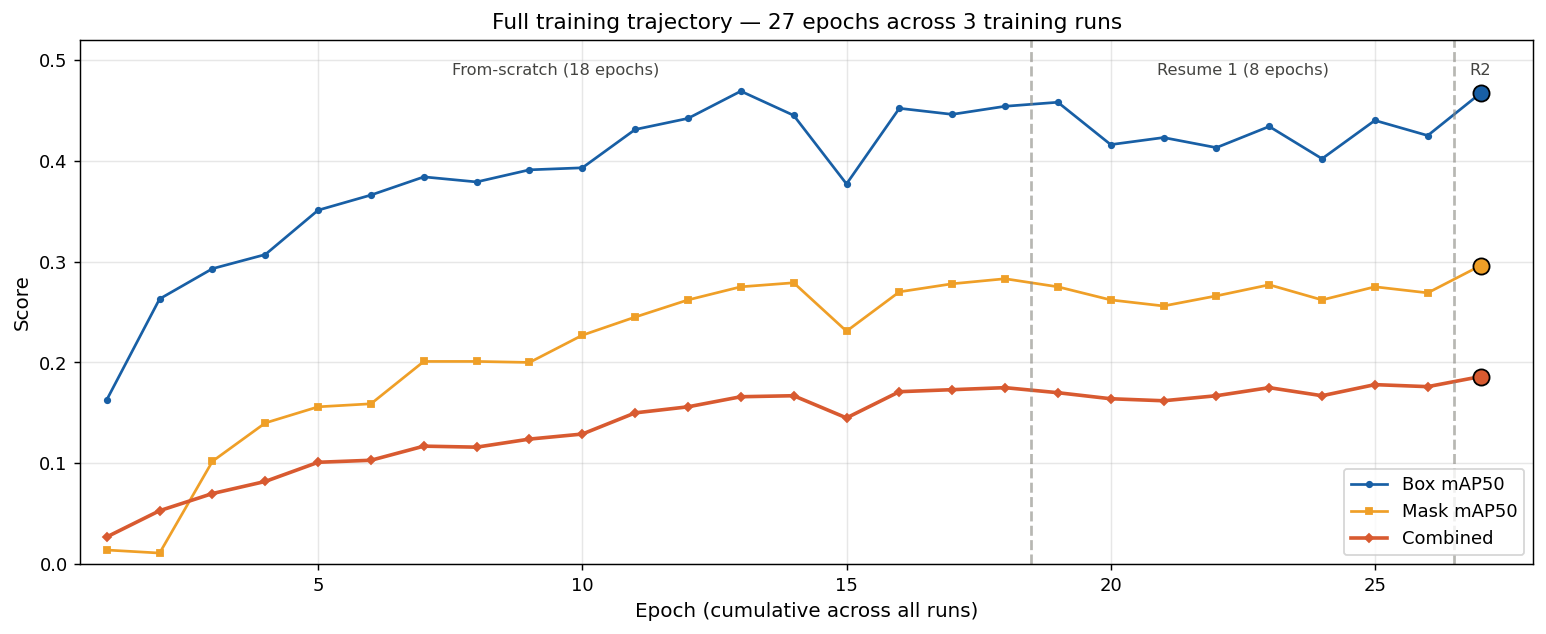

## 2. Per-class AP at multiple IoU thresholds

**Per-class AP (sorted by AP50)**

,class,AP,AP50,AP75,AP_small,AP_medium,AP_large
0,Dental implant,0.4726,0.9590,0.3776,0.4611,0.4814,NaN
1,Maxillary sinus,0.6478,0.9218,0.7978,NaN,0.0000,0.6722
2,Mandibular nerve,0.6540,0.9200,0.8218,NaN,NaN,0.6571
3,Wisdom tooth,0.4732,0.9196,0.4191,0.0000,0.4744,0.3618
4,Dental crown,0.4757,0.8664,0.4674,0.4762,0.4801,0.5543
5,Dental filling,0.2285,0.6353,0.1025,0.2145,0.2508,NaN
6,Root canal traitement,0.0440,0.1529,0.0159,0.0243,0.1007,NaN
7,Tooth decay,0.0407,0.1241,0.0145,0.0223,0.1970,NaN
8,Bone level resorption,0.0286,0.0634,0.0268,0.0000,0.0024,0.0488
9,Periodental infection,0.0202,0.0574,0.0112,0.0098,0.0320,0.6505


## 3. Per-class precision-recall curves

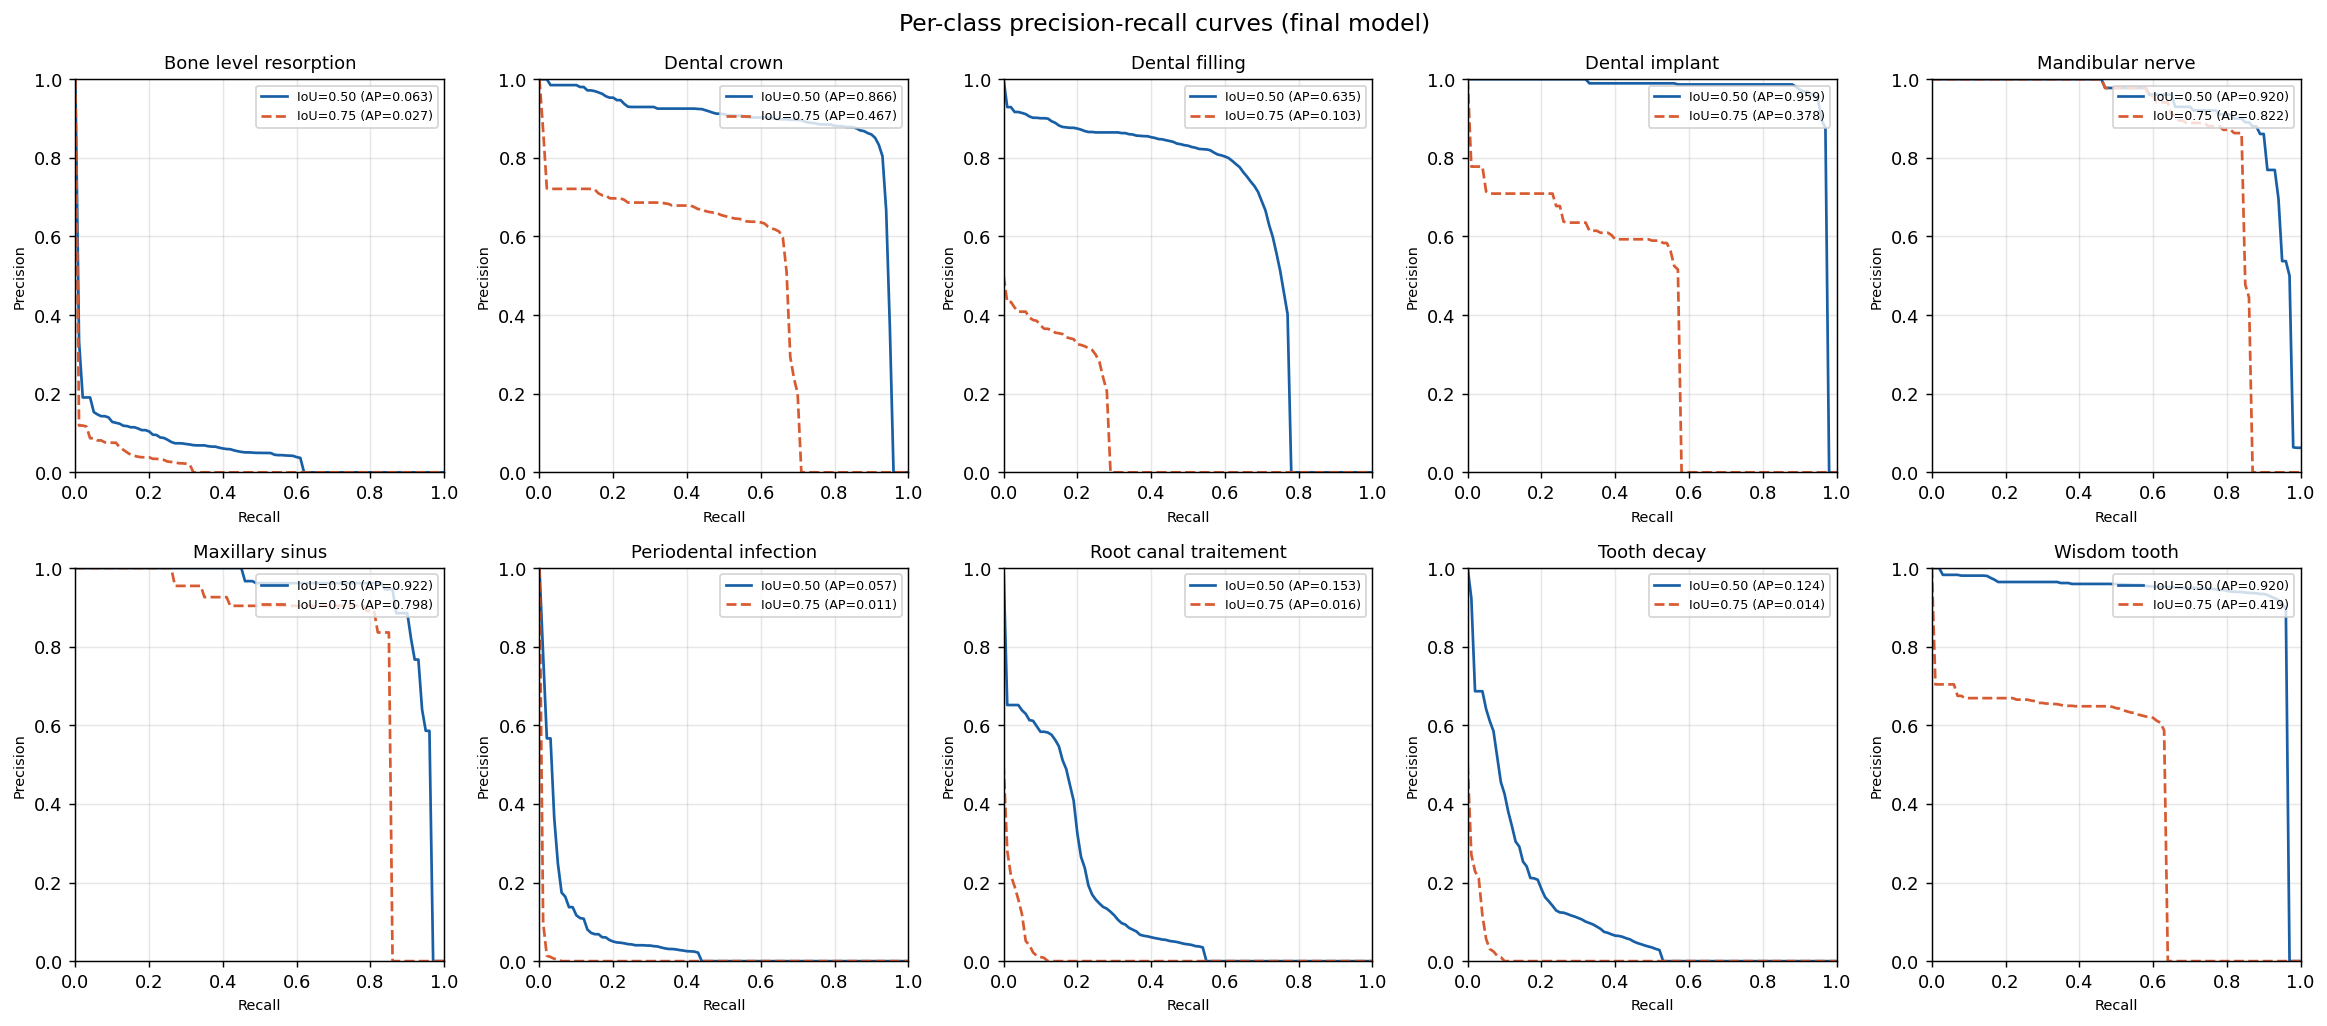

## 4. Prediction score distribution

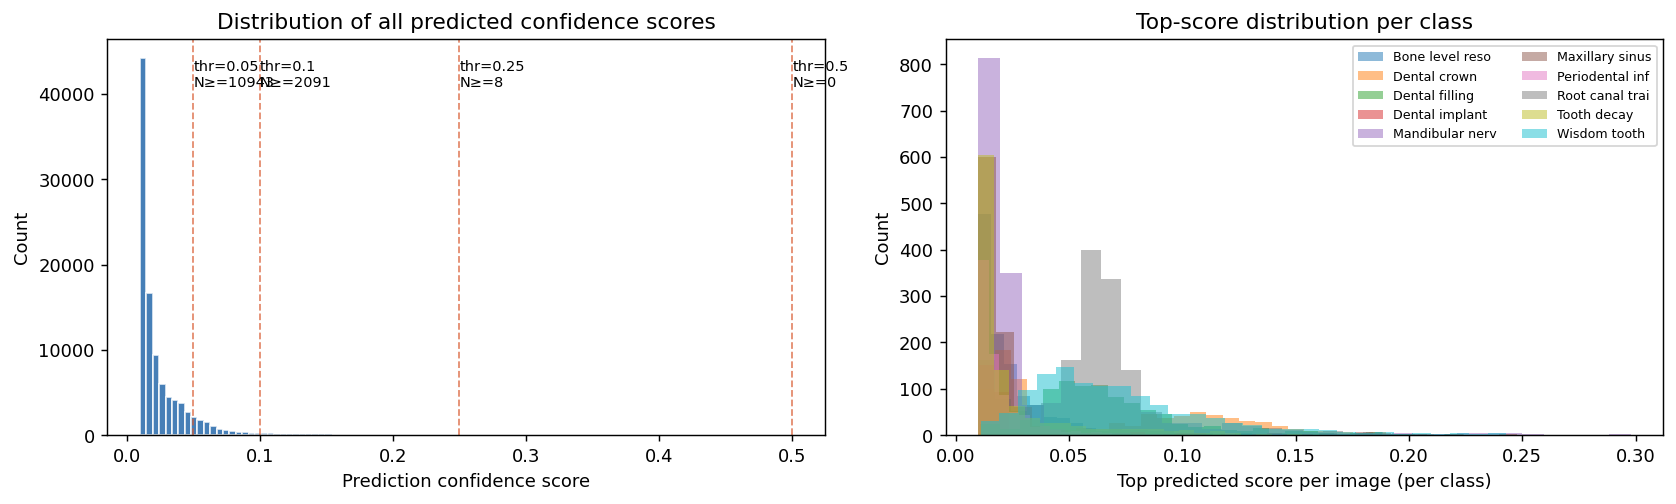

## 5. Confusion matrices at multiple thresholds

### Box confusion at score threshold 0.05

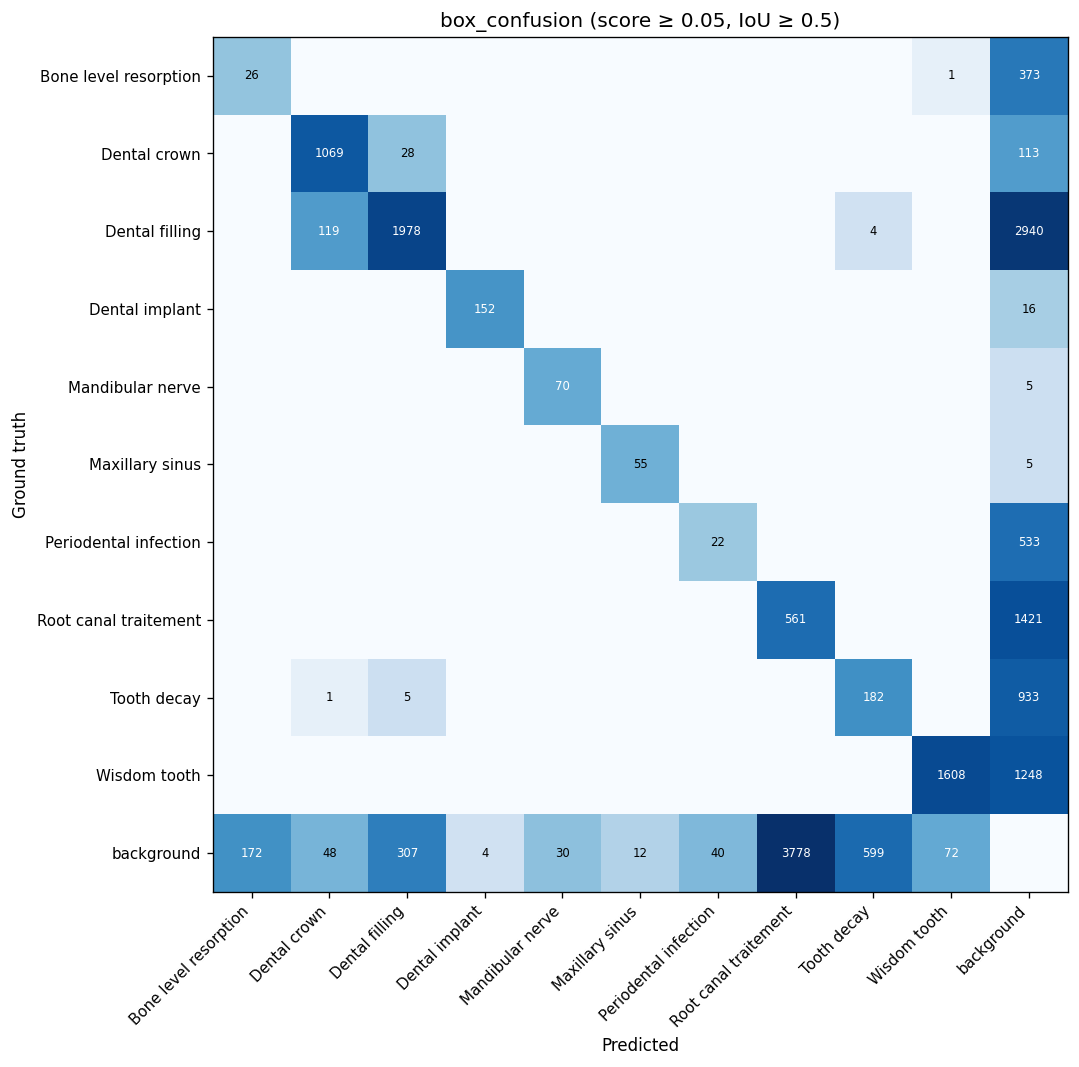

,Bone level resorption,Dental crown,Dental filling,Dental implant,Mandibular nerve,Maxillary sinus,Periodental infection,Root canal traitement,Tooth decay,Wisdom tooth,background
Bone level resorption,26,0,0,0,0,0,0,0,0,1,373
Dental crown,0,1069,28,0,0,0,0,0,0,0,113
Dental filling,0,119,1978,0,0,0,0,0,4,0,2940
Dental implant,0,0,0,152,0,0,0,0,0,0,16
Mandibular nerve,0,0,0,0,70,0,0,0,0,0,5
Maxillary sinus,0,0,0,0,0,55,0,0,0,0,5
Periodental infection,0,0,0,0,0,0,22,0,0,0,533
Root canal traitement,0,0,0,0,0,0,0,561,0,0,1421
Tooth decay,0,1,5,0,0,0,0,0,182,0,933
Wisdom tooth,0,0,0,0,0,0,0,0,0,1608,1248


### Box confusion at score threshold 0.10

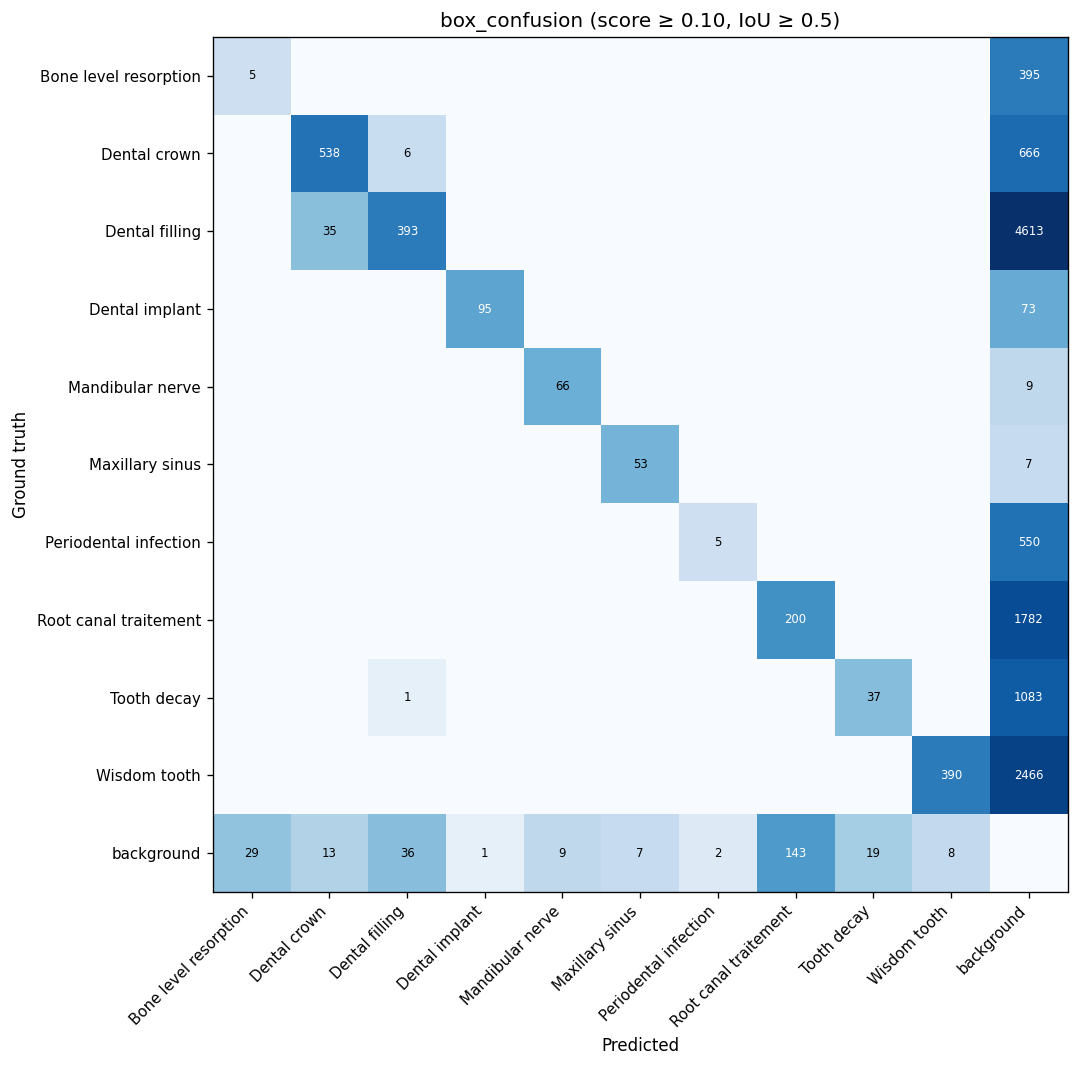

,Bone level resorption,Dental crown,Dental filling,Dental implant,Mandibular nerve,Maxillary sinus,Periodental infection,Root canal traitement,Tooth decay,Wisdom tooth,background
Bone level resorption,5,0,0,0,0,0,0,0,0,0,395
Dental crown,0,538,6,0,0,0,0,0,0,0,666
Dental filling,0,35,393,0,0,0,0,0,0,0,4613
Dental implant,0,0,0,95,0,0,0,0,0,0,73
Mandibular nerve,0,0,0,0,66,0,0,0,0,0,9
Maxillary sinus,0,0,0,0,0,53,0,0,0,0,7
Periodental infection,0,0,0,0,0,0,5,0,0,0,550
Root canal traitement,0,0,0,0,0,0,0,200,0,0,1782
Tooth decay,0,0,1,0,0,0,0,0,37,0,1083
Wisdom tooth,0,0,0,0,0,0,0,0,0,390,2466


### Box confusion at score threshold 0.25

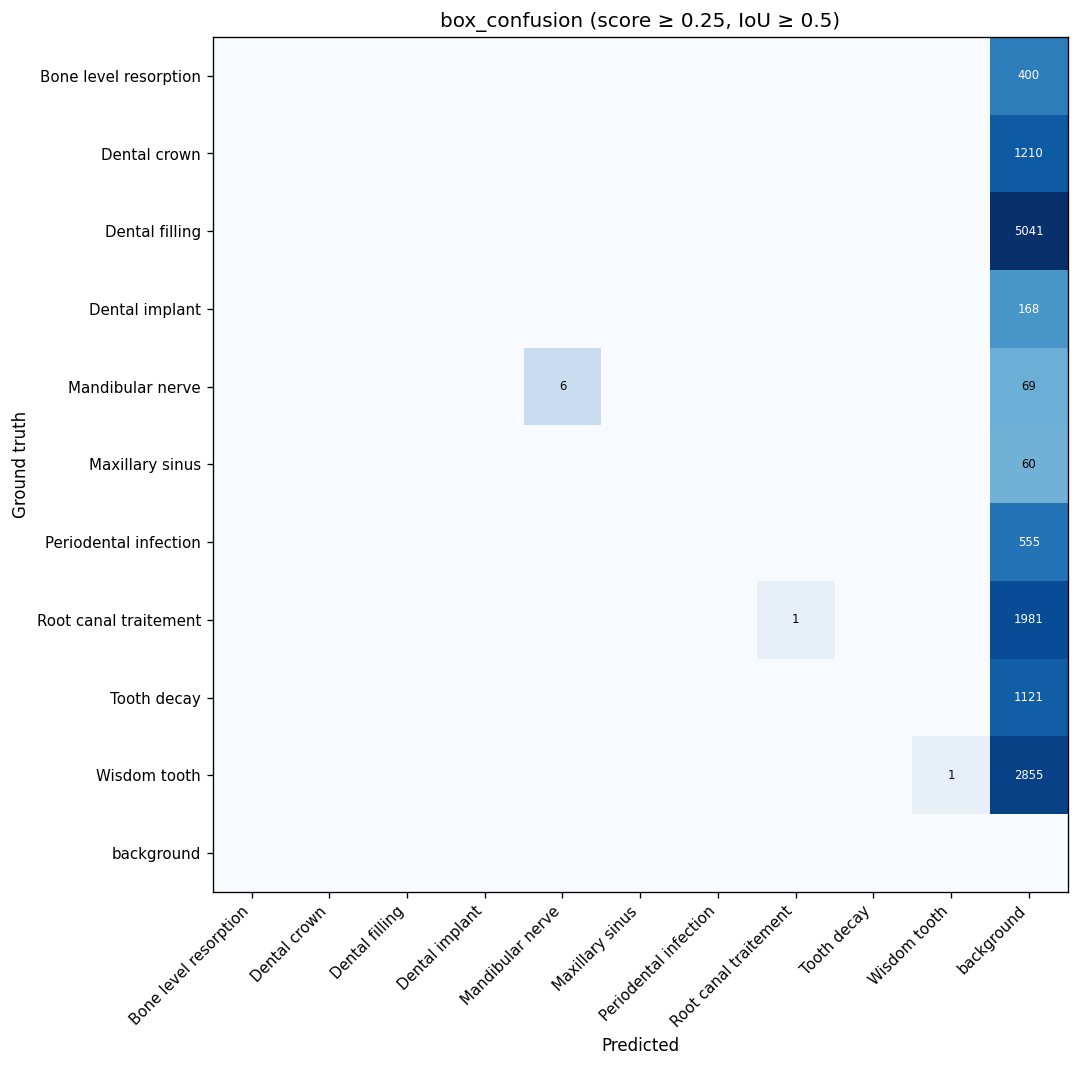

,Bone level resorption,Dental crown,Dental filling,Dental implant,Mandibular nerve,Maxillary sinus,Periodental infection,Root canal traitement,Tooth decay,Wisdom tooth,background
Bone level resorption,0,0,0,0,0,0,0,0,0,0,400
Dental crown,0,0,0,0,0,0,0,0,0,0,1210
Dental filling,0,0,0,0,0,0,0,0,0,0,5041
Dental implant,0,0,0,0,0,0,0,0,0,0,168
Mandibular nerve,0,0,0,0,6,0,0,0,0,0,69
Maxillary sinus,0,0,0,0,0,0,0,0,0,0,60
Periodental infection,0,0,0,0,0,0,0,0,0,0,555
Root canal traitement,0,0,0,0,0,0,0,1,0,0,1981
Tooth decay,0,0,0,0,0,0,0,0,0,0,1121
Wisdom tooth,0,0,0,0,0,0,0,0,0,1,2855


### Box confusion at score threshold 0.50

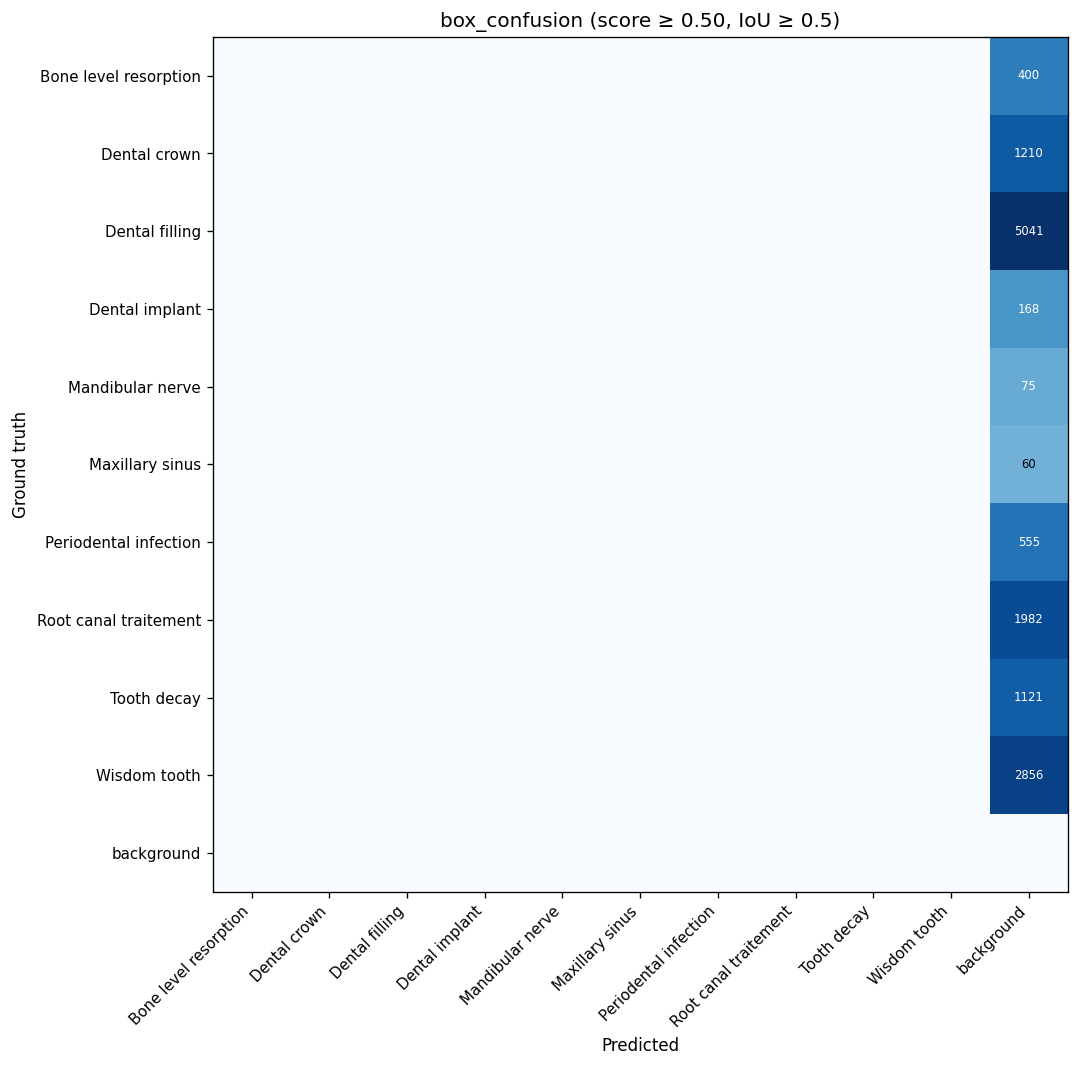

,Bone level resorption,Dental crown,Dental filling,Dental implant,Mandibular nerve,Maxillary sinus,Periodental infection,Root canal traitement,Tooth decay,Wisdom tooth,background
Bone level resorption,0,0,0,0,0,0,0,0,0,0,400
Dental crown,0,0,0,0,0,0,0,0,0,0,1210
Dental filling,0,0,0,0,0,0,0,0,0,0,5041
Dental implant,0,0,0,0,0,0,0,0,0,0,168
Mandibular nerve,0,0,0,0,0,0,0,0,0,0,75
Maxillary sinus,0,0,0,0,0,0,0,0,0,0,60
Periodental infection,0,0,0,0,0,0,0,0,0,0,555
Root canal traitement,0,0,0,0,0,0,0,0,0,0,1982
Tooth decay,0,0,0,0,0,0,0,0,0,0,1121
Wisdom tooth,0,0,0,0,0,0,0,0,0,0,2856


## 6. Qualitative prediction visualizations

*(8 images, layout: X-ray | ground truth | predictions)*

**qual_00_img7785**

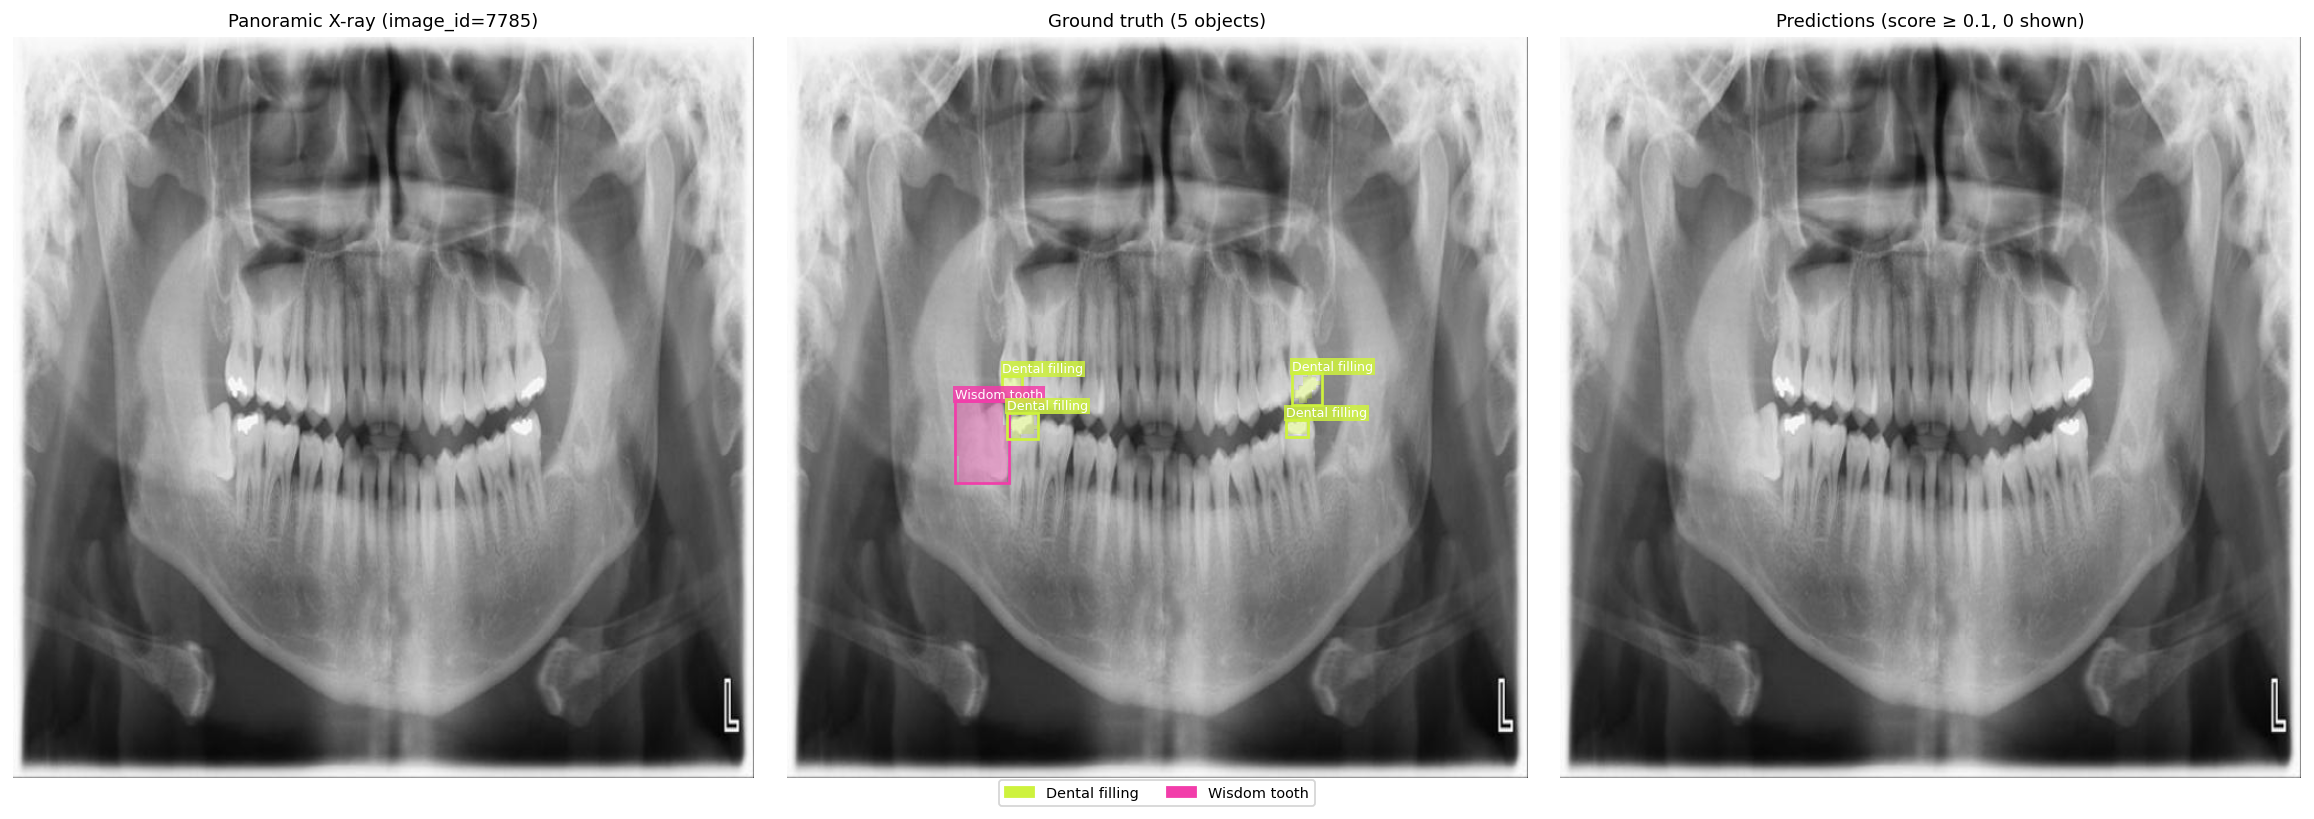

**qual_01_img1339**

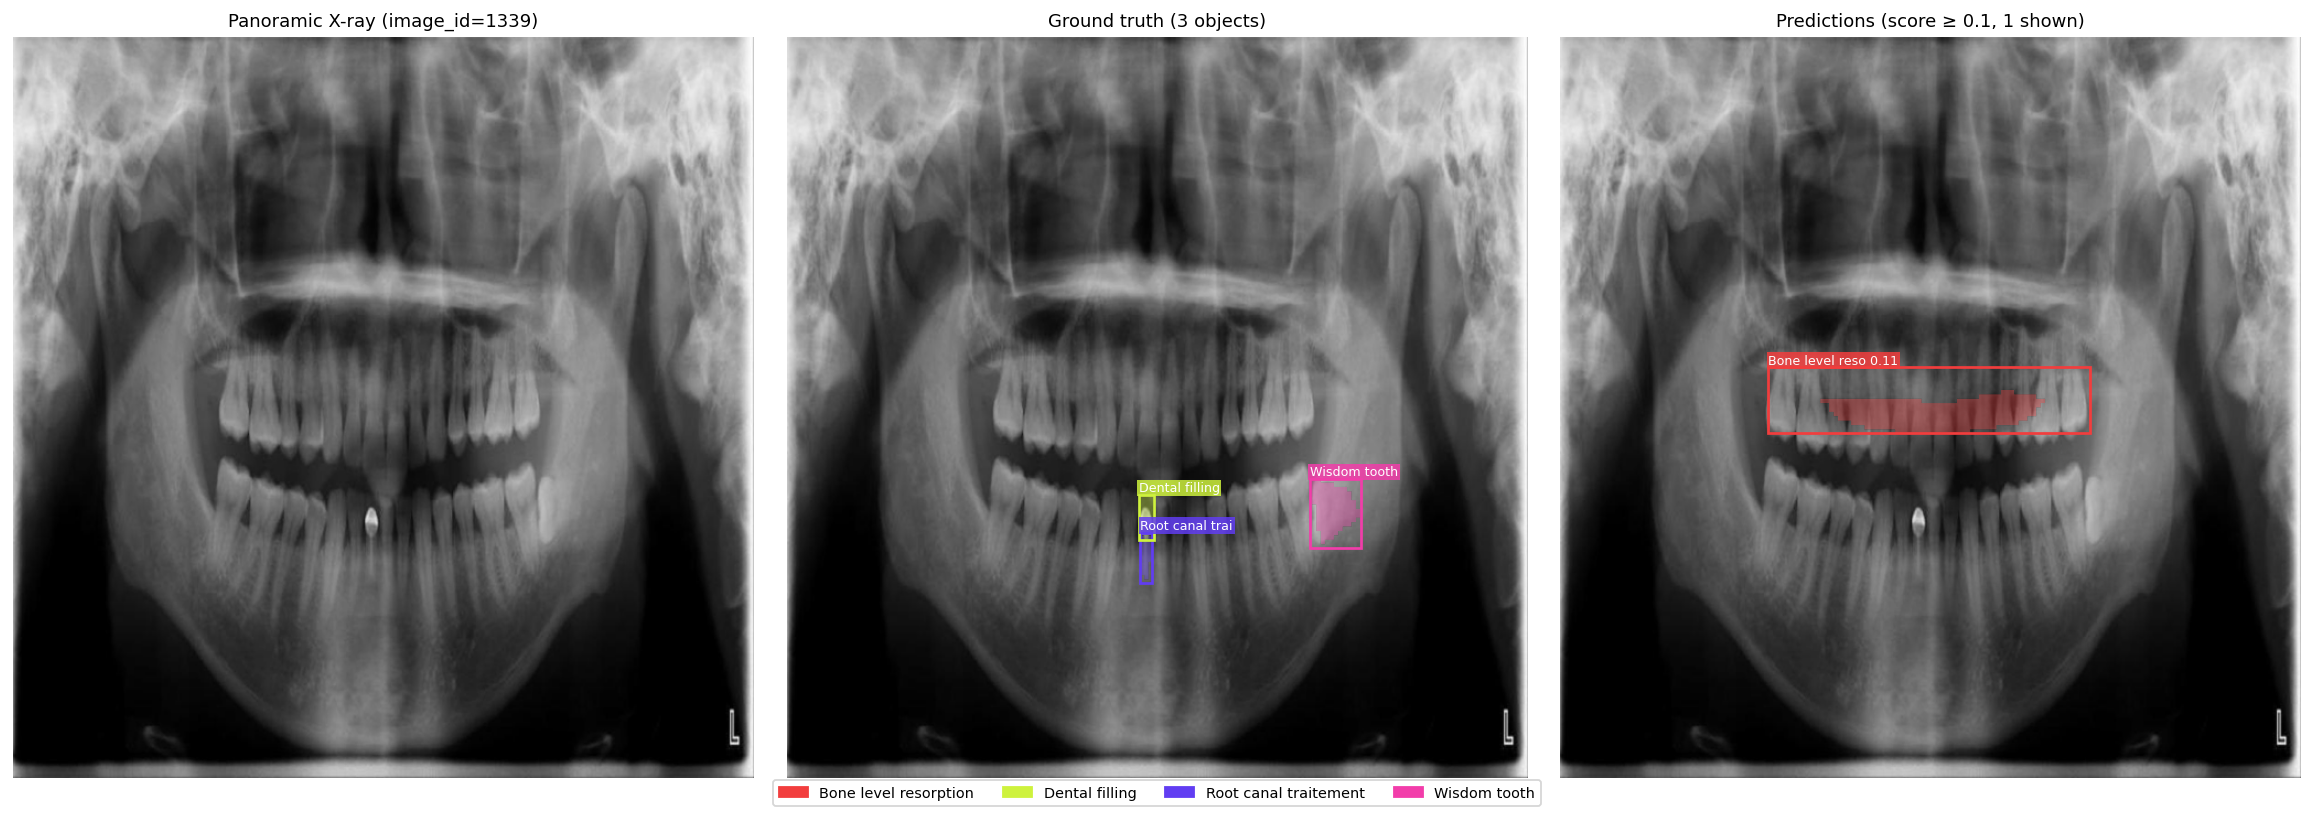

**qual_02_img285**

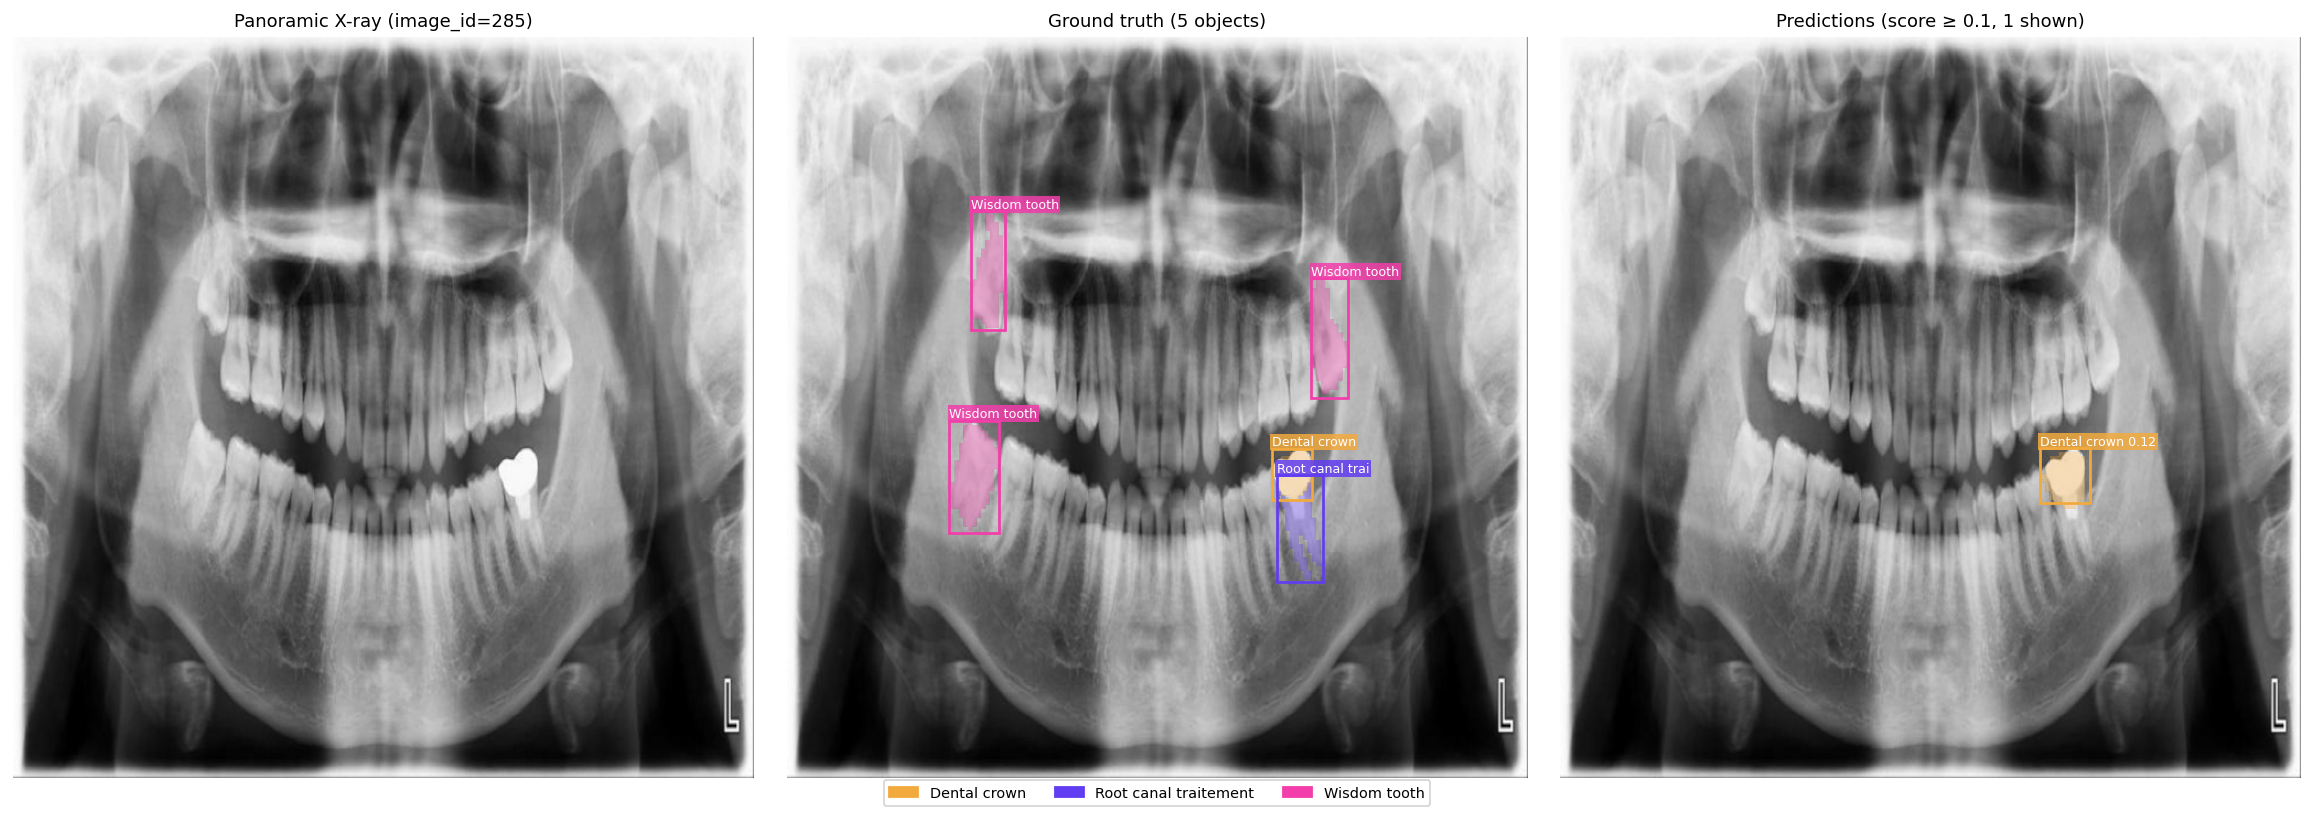

**qual_03_img9101**

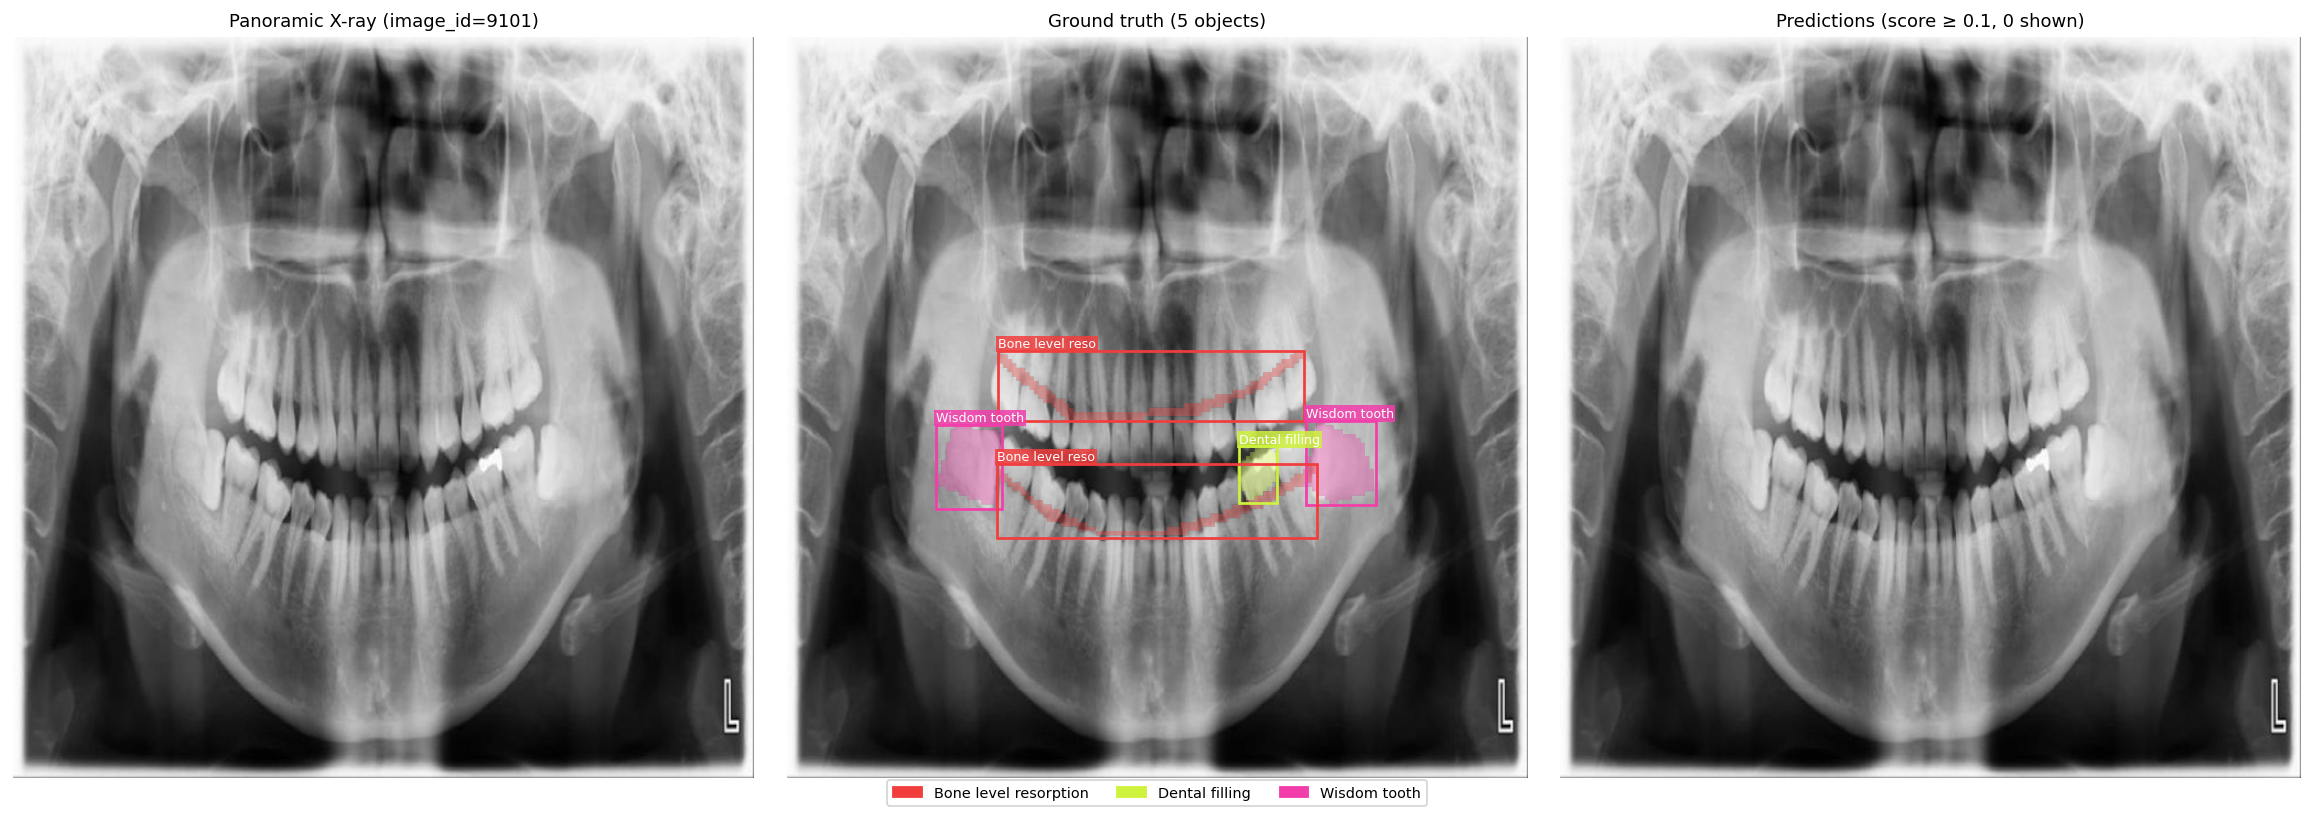

**qual_04_img3408**

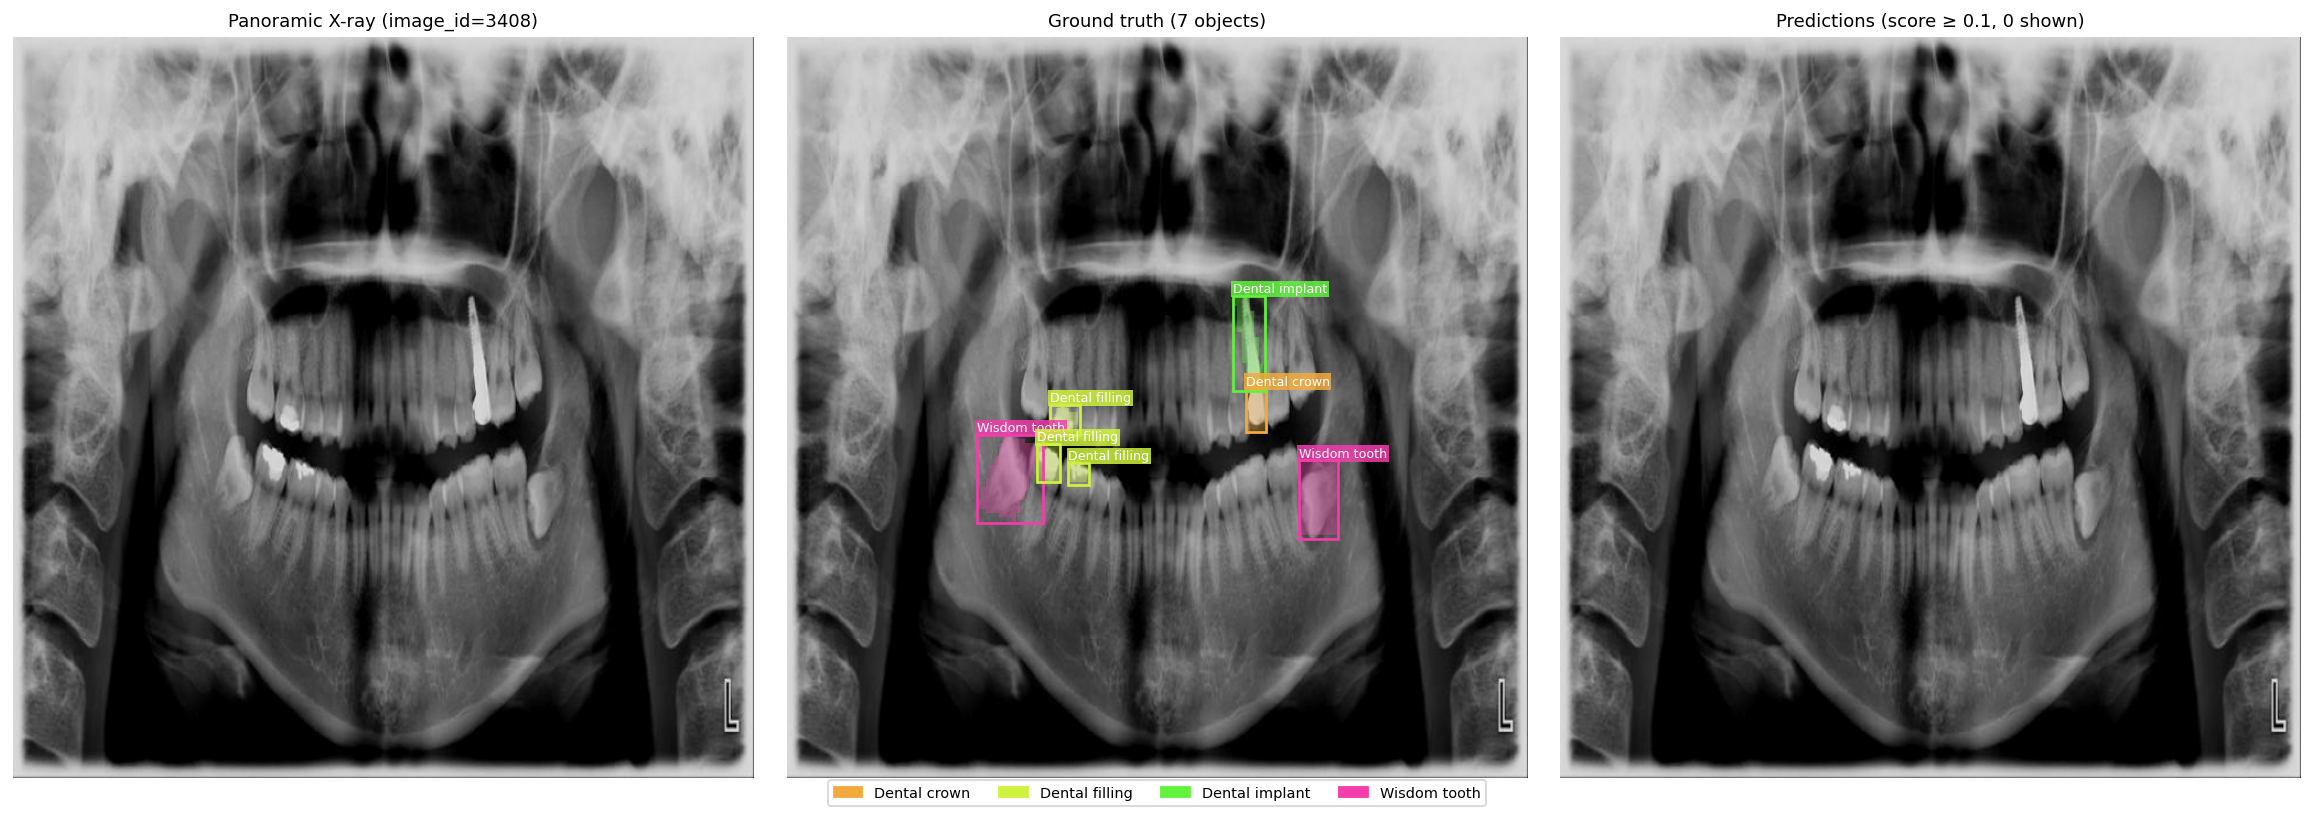

**qual_05_img3082**

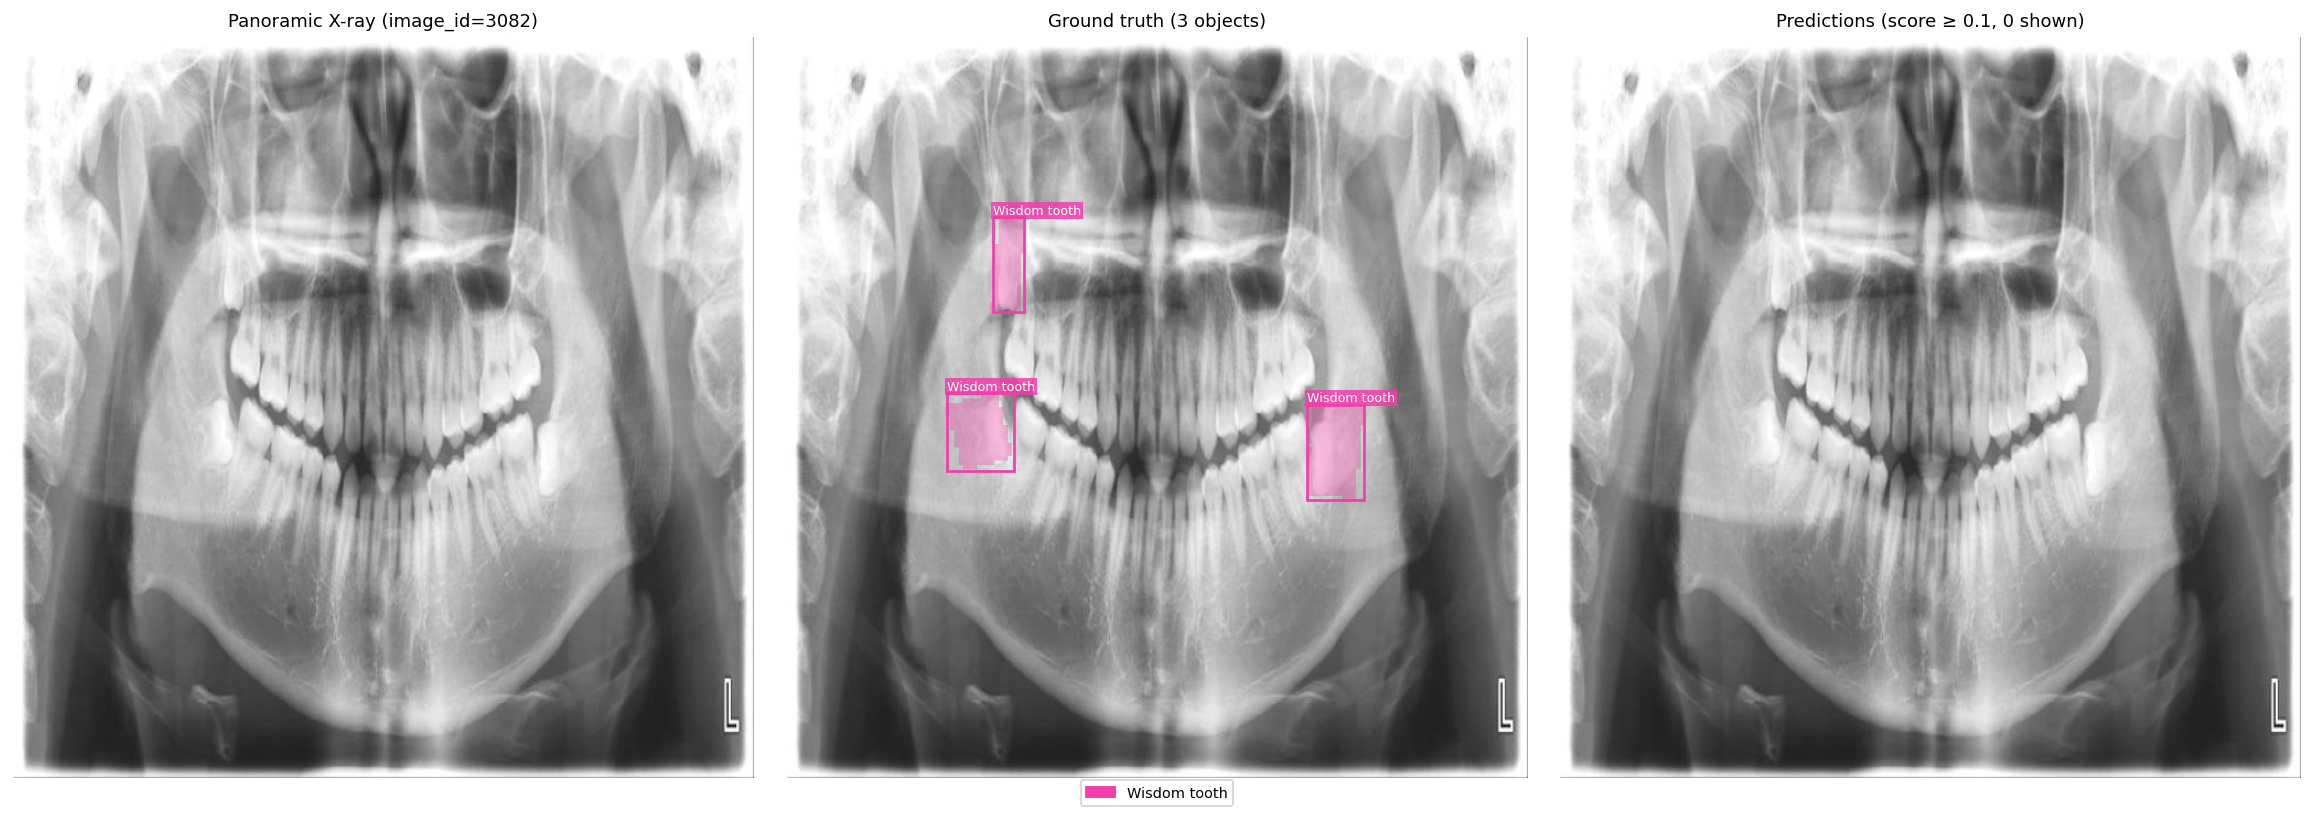

**qual_06_img2817**

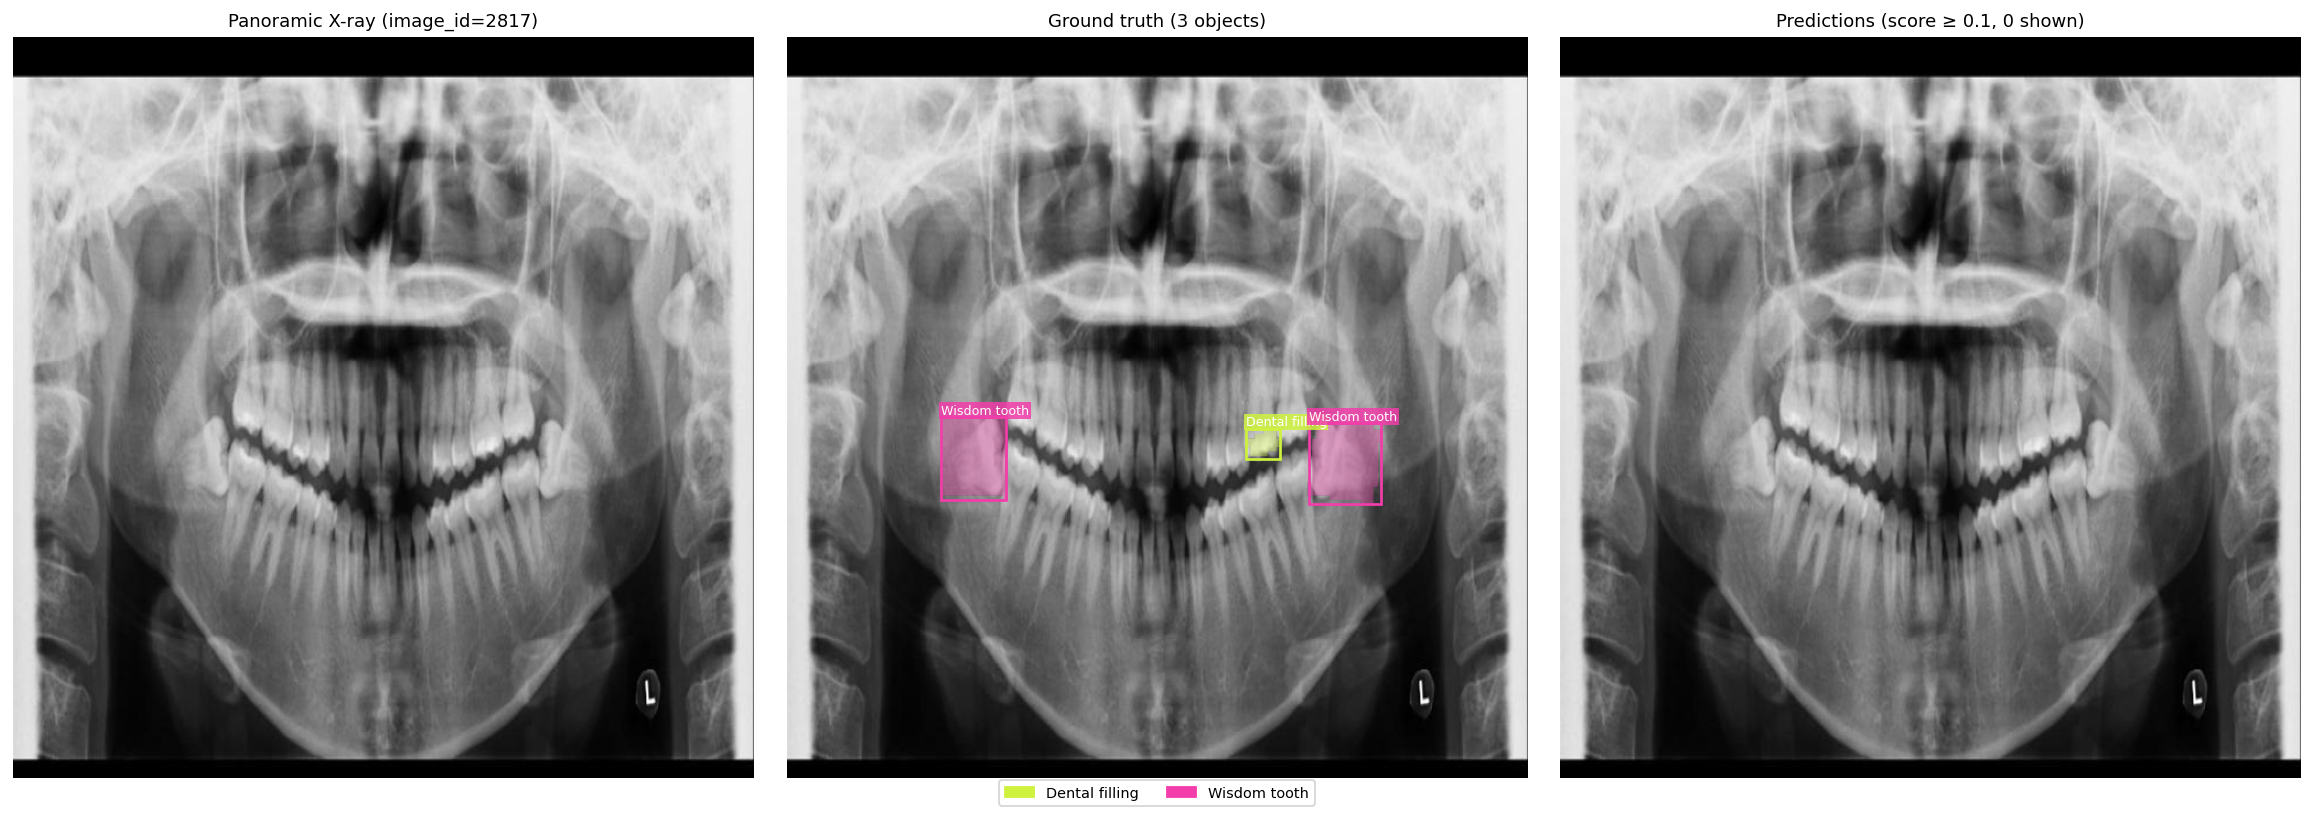

**qual_07_img1713**

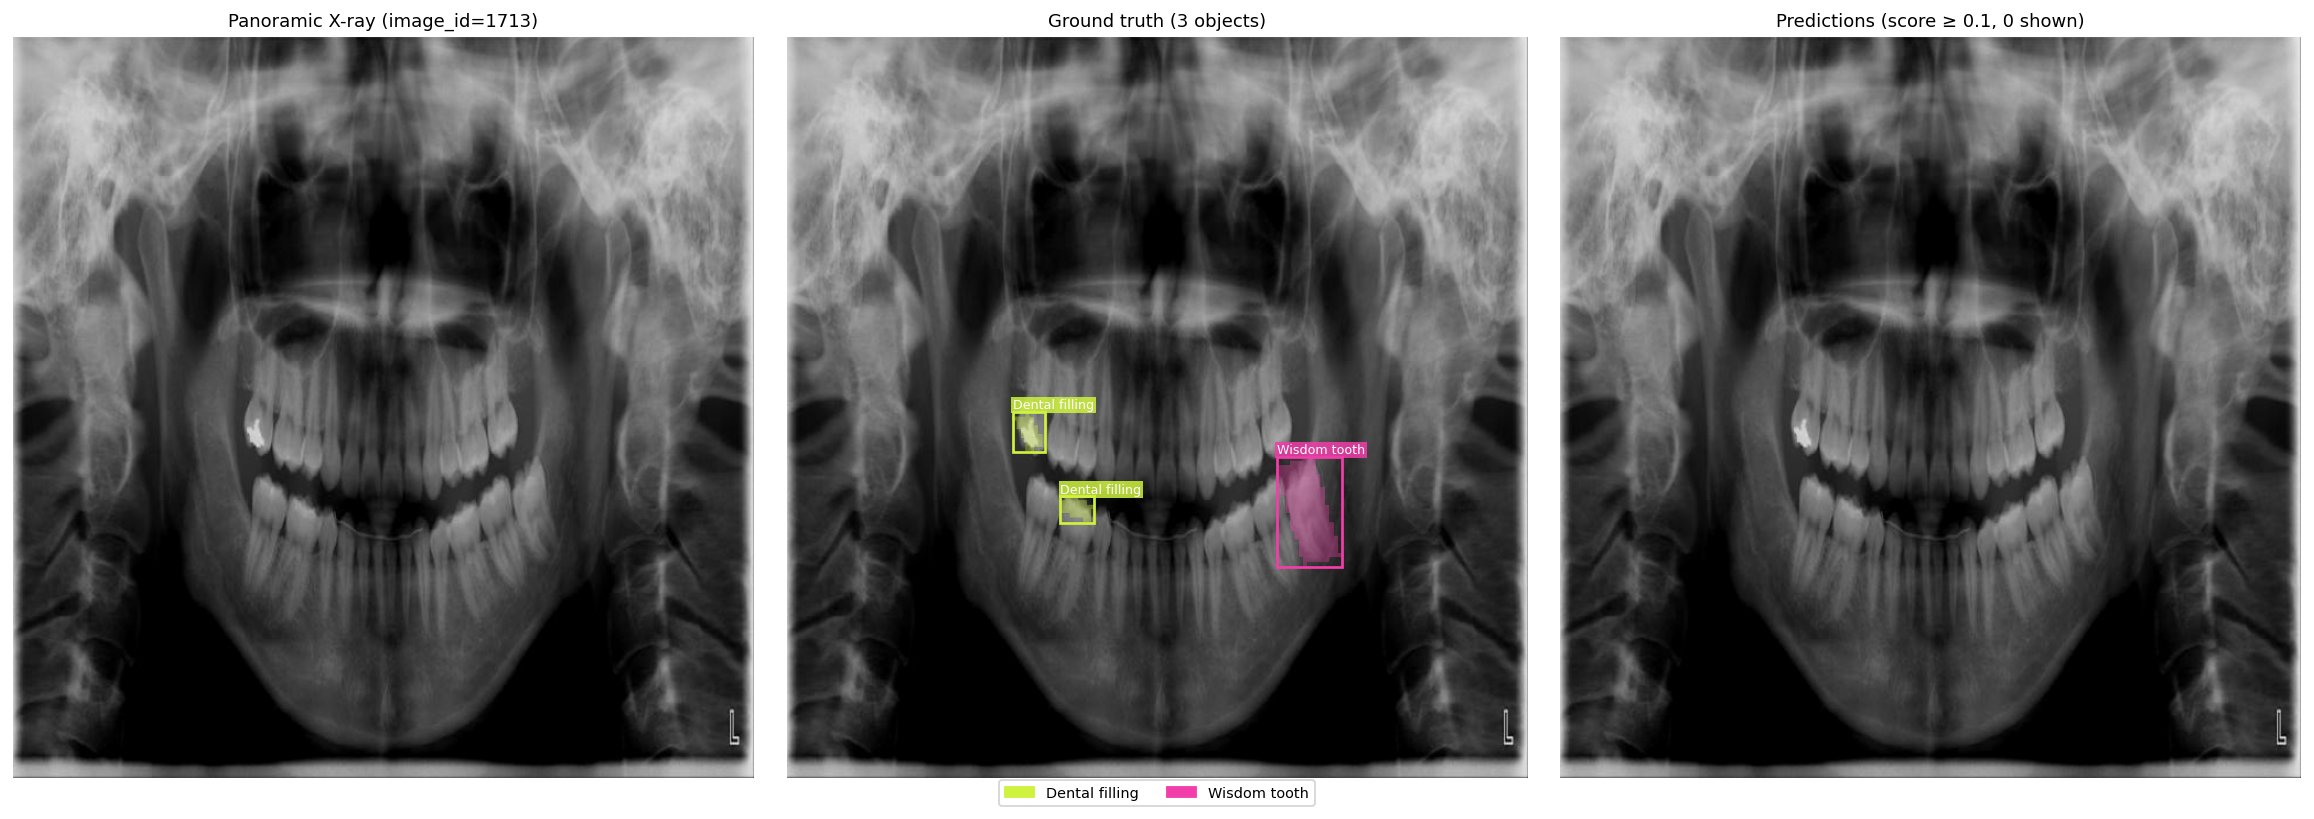

## 7. Summary numbers


| Metric | Value |
|---|---|
| Checkpoint | `a4_plain56_multiscale_t4safe_resume2_5h_best_box_map50.pt` |
| Validation images | 1400 |
| Total ground-truth objects | 13,468 |
| Total predictions (score > 0.01) | 103,114 |
| Avg predictions per image | 73.7 |


## 8. All saved output files

,path,size_KB
0,coco_dt.json,15291
1,coco_gt.json,2340
2,confusion_matrices/box_confusion_thr005.csv,0
3,confusion_matrices/box_confusion_thr005.png,96
4,confusion_matrices/box_confusion_thr010.csv,0
5,confusion_matrices/box_confusion_thr010.png,94
6,confusion_matrices/box_confusion_thr025.csv,0
7,confusion_matrices/box_confusion_thr025.png,87
8,confusion_matrices/box_confusion_thr050.csv,0
9,confusion_matrices/box_confusion_thr050.png,87


**Zip available at:** `/kaggle/working/analysis_outputs.zip`

Download the zip from the Kaggle notebook output panel to get all figures and CSVs for the report.

In [27]:
# ============================================================
# DISPLAY ALL ANALYSIS OUTPUTS INLINE
# ============================================================
# Shows every produced artifact in the notebook itself (confusion matrices,
# PR curves, qualitative visualizations, tables, training trajectory).
# Nothing new is computed — this just renders what the previous cells saved.

from IPython.display import display, Image as IPyImage, Markdown, HTML
import pandas as pd
from pathlib import Path

def _section(title):
    display(Markdown(f'## {title}'))

def _subsection(title):
    display(Markdown(f'### {title}'))

def _show_image(path, caption=None):
    path = Path(path)
    if not path.exists():
        display(Markdown(f'*(missing: `{path.name}`)*'))
        return
    if caption:
        display(Markdown(f'**{caption}**'))
    display(IPyImage(filename=str(path)))

def _show_csv(path, caption=None, float_fmt='{:.4f}', max_rows=None):
    path = Path(path)
    if not path.exists():
        display(Markdown(f'*(missing: `{path.name}`)*'))
        return
    df = pd.read_csv(path, index_col=0) if 'confusion' in path.name else pd.read_csv(path)
    if caption:
        display(Markdown(f'**{caption}**'))
    with pd.option_context('display.max_columns', None, 'display.width', 200, 'display.float_format', float_fmt.format):
        display(df if max_rows is None else df.head(max_rows))

display(Markdown('# Final model analysis — inline results'))
display(Markdown(f'**Checkpoint:** `{RESUME_CKPT.name}`'))
display(Markdown(f'**Validation images:** {len(all_preds)}'))
display(Markdown(f'**Total GT objects:** {sum(len(g["labels"]) for g in all_gts)}'))

_section('1. Training trajectory (all 27 epochs)')
_show_image(ANALYSIS_DIR / 'training_trajectory.png')

_section('2. Per-class AP at multiple IoU thresholds')
_show_csv(ANALYSIS_DIR / 'per_class_multi_iou.csv', caption='Per-class AP (sorted by AP50)')

_section('3. Per-class precision-recall curves')
_show_image(PR_DIR / 'per_class_pr_curves.png')

_section('4. Prediction score distribution')
_show_image(ANALYSIS_DIR / 'score_distribution.png')

_section('5. Confusion matrices at multiple thresholds')
for thr in [0.05, 0.10, 0.25, 0.50]:
    _subsection(f'Box confusion at score threshold {thr:.2f}')
    _show_image(CM_DIR / f'box_confusion_thr{int(thr*100):03d}.png')
    _show_csv(CM_DIR / f'box_confusion_thr{int(thr*100):03d}.csv', float_fmt='{:.0f}')

_section('6. Qualitative prediction visualizations')
qual_images = sorted(QUAL_DIR.glob('qual_*.png'))
display(Markdown(f'*({len(qual_images)} images, layout: X-ray | ground truth | predictions)*'))
for qp in qual_images:
    _show_image(qp, caption=qp.stem)

_section('7. Summary numbers')
total_preds = sum(len(p['scores']) for p in all_preds)
total_gts = sum(len(g['labels']) for g in all_gts)
summary_md = f'''
| Metric | Value |
|---|---|
| Checkpoint | `{RESUME_CKPT.name}` |
| Validation images | {len(all_preds)} |
| Total ground-truth objects | {total_gts:,} |
| Total predictions (score > 0.01) | {total_preds:,} |
| Avg predictions per image | {total_preds / max(1, len(all_preds)):.1f} |
'''
display(Markdown(summary_md))

_section('8. All saved output files')
file_rows = []
for p in sorted(ANALYSIS_DIR.rglob('*')):
    if p.is_file():
        rel = p.relative_to(ANALYSIS_DIR)
        file_rows.append({'path': str(rel), 'size_KB': p.stat().st_size // 1024})
files_df = pd.DataFrame(file_rows)
display(files_df)

display(Markdown(f'**Zip available at:** `{WORK_DIR / "analysis_outputs.zip"}`'))
display(Markdown('Download the zip from the Kaggle notebook output panel to get all figures and CSVs for the report.'))


---

# Extended analysis

Four additions on top of the existing bbox analysis:

1. **COCO mask AP** (full segmentation metrics alongside bbox)
2. **Threshold sweep** (TP/FP/FN at 8 thresholds from 0.01 to 0.25)
3. **Per-class best threshold** (each class optimized independently by F1)
4. **Error taxonomy for weak classes** (why bone resorption, periodontal infection, root canal, and tooth decay underperform)

Plus a final honest comparison table covering A4 plain, A5 LoRA (preliminary), and the reported YOLO-seg baseline.

No new inference is run — everything operates on the predictions and ground truth already collected in memory (`all_preds`, `all_gts`).


In [28]:
# ── COCO mask AP (addition #1) ──
# Build RLE-encoded mask predictions and GT, then run COCOeval in 'segm' mode.

import pycocotools.mask as coco_mask_utils
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO as _COCO

print('Building COCO-format mask annotations (RLE-encoded)...')

# Build GT and DT with RLE segmentations
mask_gt_anns = []
ann_id = 1
mask_images = [{'id': int(gid), 'height': STORED_MASK_SIZE, 'width': STORED_MASK_SIZE} for gid in all_image_ids]
mask_categories = [{'id': i + 1, 'name': CLASS_NAMES[i]} for i in range(NUM_CLASSES)]

for g in all_gts:
    for bi in range(len(g['labels'])):
        m = np.asfortranarray(g['masks'][bi].astype(np.uint8))
        if m.sum() == 0:
            continue
        rle = coco_mask_utils.encode(m)
        rle['counts'] = rle['counts'].decode('utf-8')
        ys, xs = np.where(g['masks'][bi])
        if len(xs) == 0:
            continue
        x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
        mask_gt_anns.append({
            'id': ann_id,
            'image_id': int(g['image_id']),
            'category_id': int(g['labels'][bi]) + 1,
            'segmentation': rle,
            'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
            'area': int(m.sum()),
            'iscrowd': 0,
        })
        ann_id += 1

mask_dt = []
for p in all_preds:
    for pi in range(len(p['scores'])):
        m = np.asfortranarray(p['masks'][pi].astype(np.uint8))
        if m.sum() == 0:
            continue
        rle = coco_mask_utils.encode(m)
        rle['counts'] = rle['counts'].decode('utf-8')
        mask_dt.append({
            'image_id': int(p['image_id']),
            'category_id': int(p['labels'][pi]) + 1,
            'segmentation': rle,
            'score': float(p['scores'][pi]),
        })

print(f'GT mask annotations: {len(mask_gt_anns):,}')
print(f'Predicted mask annotations: {len(mask_dt):,}')

mask_gt_dict = {'images': mask_images, 'annotations': mask_gt_anns, 'categories': mask_categories}
coco_gt_mask = _COCO()
coco_gt_mask.dataset = mask_gt_dict
coco_gt_mask.createIndex()
coco_dt_mask = coco_gt_mask.loadRes(mask_dt)

print('\n=== MASK (segm) EVALUATION ===')
mask_eval = COCOeval(coco_gt_mask, coco_dt_mask, iouType='segm')
mask_eval.evaluate()
mask_eval.accumulate()
mask_eval.summarize()

# Build the combined bbox+mask summary table
def summarize_ap(cocoeval):
    stats = cocoeval.stats  # [AP, AP50, AP75, AP_s, AP_m, AP_l, AR_max1, AR_max10, AR_max100, AR_s, AR_m, AR_l]
    return {
        'AP': stats[0],
        'AP50': stats[1],
        'AP75': stats[2],
        'AP_small': stats[3],
        'AP_medium': stats[4],
        'AP_large': stats[5],
        'AR_100': stats[8],
    }

# The bbox eval was already done in an earlier cell as 'evaluator' (iouType='bbox')
bbox_ap = summarize_ap(evaluator)
mask_ap = summarize_ap(mask_eval)

summary_df = pd.DataFrame({'BBox': bbox_ap, 'Mask': mask_ap}).T
summary_df = summary_df[['AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large', 'AR_100']]
summary_df.to_csv(ANALYSIS_DIR / 'bbox_vs_mask_summary.csv')
print('\n=== BBOX vs MASK AP SUMMARY ===')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print(summary_df.to_string())
print(f'\nSaved to {ANALYSIS_DIR / "bbox_vs_mask_summary.csv"}')


Building COCO-format mask annotations (RLE-encoded)...
GT mask annotations: 13,447
Predicted mask annotations: 67,985
creating index...
index created!
Loading and preparing results...
DONE (t=0.50s)
creating index...
index created!

=== MASK (segm) EVALUATION ===
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=7.03s).
Accumulating evaluation results...
DONE (t=0.80s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.347
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.041
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.107
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.248
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.077
 Average Recall     (AR) @[ IoU=0.50:0.95 | 

In [29]:
# ── Threshold sweep (addition #2) ──
# For each threshold, compute TP / FP / FN / Precision / Recall / F1 / FP-per-image
# using IoU matching at 0.50 (same as confusion matrices).

thresholds_sweep = [0.01, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25]
num_images = len(all_preds)

def compute_prf_at_threshold(all_preds, all_gts, score_thr, iou_thr=0.5):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    for p, g in zip(all_preds, all_gts):
        keep = p['scores'] >= score_thr
        pboxes = p['boxes'][keep]
        plabels = p['labels'][keep]
        pscores = p['scores'][keep]
        order = np.argsort(-pscores)
        pboxes = pboxes[order]
        plabels = plabels[order]
        gboxes = g['boxes']
        glabels = g['labels']
        gt_matched = np.zeros(len(gboxes), dtype=bool)
        if len(pboxes) > 0 and len(gboxes) > 0:
            iou = compute_box_iou(pboxes, gboxes)
            for pi in range(len(pboxes)):
                best_gi = -1
                best_iou = iou_thr
                for gi in range(len(gboxes)):
                    if gt_matched[gi]:
                        continue
                    if glabels[gi] != plabels[pi]:
                        continue  # only same-class counts as TP
                    if iou[pi, gi] >= best_iou:
                        best_iou = iou[pi, gi]
                        best_gi = gi
                if best_gi >= 0:
                    total_tp += 1
                    gt_matched[best_gi] = True
                else:
                    total_fp += 1
        elif len(pboxes) > 0:
            total_fp += len(pboxes)
        total_fn += int((~gt_matched).sum())
    precision = total_tp / max(1, total_tp + total_fp)
    recall = total_tp / max(1, total_tp + total_fn)
    f1 = (2 * precision * recall / max(1e-9, precision + recall)) if (precision + recall) > 0 else 0.0
    fp_per_image = total_fp / max(1, num_images)
    return total_tp, total_fp, total_fn, precision, recall, f1, fp_per_image

sweep_rows = []
for thr in thresholds_sweep:
    tp, fp, fn, prec, rec, f1, fpi = compute_prf_at_threshold(all_preds, all_gts, thr)
    sweep_rows.append({
        'threshold': thr, 'TP': tp, 'FP': fp, 'FN': fn,
        'precision': prec, 'recall': rec, 'F1': f1, 'FP_per_image': fpi,
    })
sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(ANALYSIS_DIR / 'threshold_sweep.csv', index=False)
print('=== THRESHOLD SWEEP (IoU 0.50, same-class matching) ===')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print(sweep_df.to_string(index=False))

# Plot F1 and FP/image vs threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep_df['threshold'], sweep_df['precision'], 'o-', color='#185FA5', label='Precision')
axes[0].plot(sweep_df['threshold'], sweep_df['recall'], 's-', color='#D85A30', label='Recall')
axes[0].plot(sweep_df['threshold'], sweep_df['F1'], 'D-', color='#1D9E75', label='F1')
axes[0].set_xlabel('Score threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs threshold')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(sweep_df['threshold'], sweep_df['FP_per_image'], 'o-', color='#D85A30')
axes[1].set_xlabel('Score threshold')
axes[1].set_ylabel('False positives per image')
axes[1].set_title('FP/image vs threshold')
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'threshold_sweep.png', dpi=130, bbox_inches='tight')
plt.close(fig)

best_f1_row = sweep_df.loc[sweep_df['F1'].idxmax()]
print(f'\nBest global F1 = {best_f1_row["F1"]:.4f} at threshold {best_f1_row["threshold"]:.2f}')
print(f'  TP={int(best_f1_row["TP"])}, FP={int(best_f1_row["FP"])}, FN={int(best_f1_row["FN"])}')
print(f'  Precision={best_f1_row["precision"]:.4f}, Recall={best_f1_row["recall"]:.4f}')


=== THRESHOLD SWEEP (IoU 0.50, same-class matching) ===
 threshold    TP    FP    FN  precision  recall     F1  FP_per_image
    0.0100 10250 92864  3218     0.0994  0.7611 0.1758       66.3314
    0.0300  8257 17832  5211     0.3165  0.6131 0.4175       12.7371
    0.0500  5725  5218  7743     0.5232  0.4251 0.4691        3.7271
    0.0700  3585  1200  9883     0.7492  0.2662 0.3928        0.8571
    0.1000  1783   308 11685     0.8527  0.1324 0.2292        0.2200
    0.1500   460    51 13008     0.9002  0.0342 0.0658        0.0364
    0.2000    93     4 13375     0.9588  0.0069 0.0137        0.0029
    0.2500     8     0 13460     1.0000  0.0006 0.0012        0.0000

Best global F1 = 0.4691 at threshold 0.05
  TP=5725, FP=5218, FN=7743
  Precision=0.5232, Recall=0.4251


In [30]:
# ── Per-class best threshold (addition #3) ──
# Each class gets its own optimal threshold based on F1 (class-conditional).

def compute_prf_per_class(all_preds, all_gts, score_thr, cls, iou_thr=0.5):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    for p, g in zip(all_preds, all_gts):
        # Only same-class predictions
        keep = (p['scores'] >= score_thr) & (p['labels'] == cls)
        pboxes = p['boxes'][keep]
        pscores = p['scores'][keep]
        order = np.argsort(-pscores)
        pboxes = pboxes[order]
        gmask = (g['labels'] == cls)
        gboxes = g['boxes'][gmask]
        gt_matched = np.zeros(len(gboxes), dtype=bool)
        if len(pboxes) > 0 and len(gboxes) > 0:
            iou = compute_box_iou(pboxes, gboxes)
            for pi in range(len(pboxes)):
                best_gi = -1
                best_iou = iou_thr
                for gi in range(len(gboxes)):
                    if gt_matched[gi]:
                        continue
                    if iou[pi, gi] >= best_iou:
                        best_iou = iou[pi, gi]
                        best_gi = gi
                if best_gi >= 0:
                    total_tp += 1
                    gt_matched[best_gi] = True
                else:
                    total_fp += 1
        elif len(pboxes) > 0:
            total_fp += len(pboxes)
        total_fn += int((~gt_matched).sum())
    precision = total_tp / max(1, total_tp + total_fp)
    recall = total_tp / max(1, total_tp + total_fn)
    f1 = (2 * precision * recall / max(1e-9, precision + recall)) if (precision + recall) > 0 else 0.0
    return total_tp, total_fp, total_fn, precision, recall, f1

per_class_best = []
for ci in range(NUM_CLASSES):
    best_f1 = -1
    best_row = None
    for thr in thresholds_sweep:
        tp, fp, fn, prec, rec, f1 = compute_prf_per_class(all_preds, all_gts, thr, ci)
        if f1 > best_f1:
            best_f1 = f1
            best_row = {
                'class': CLASS_NAMES[ci], 'best_threshold': thr,
                'TP': tp, 'FP': fp, 'FN': fn,
                'precision': prec, 'recall': rec, 'F1': f1,
            }
    per_class_best.append(best_row if best_row else {'class': CLASS_NAMES[ci], 'best_threshold': None, 'TP': 0, 'FP': 0, 'FN': 0, 'precision': 0, 'recall': 0, 'F1': 0})

per_class_best_df = pd.DataFrame(per_class_best).sort_values('F1', ascending=False)
per_class_best_df.to_csv(ANALYSIS_DIR / 'per_class_best_threshold.csv', index=False)
print('=== PER-CLASS BEST THRESHOLD (by F1) ===')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print(per_class_best_df.to_string(index=False))


=== PER-CLASS BEST THRESHOLD (by F1) ===
                class  best_threshold   TP  FP   FN  precision  recall     F1
       Dental implant          0.0300  161  12    7     0.9306  0.9583 0.9443
         Wisdom tooth          0.0100 2765 430   91     0.8654  0.9681 0.9139
      Maxillary sinus          0.0700   54   8    6     0.8710  0.9000 0.8852
     Mandibular nerve          0.1000   66   9    9     0.8800  0.8800 0.8800
         Dental crown          0.0500 1070 167  140     0.8650  0.8843 0.8745
       Dental filling          0.0300 3118 816 1923     0.7926  0.6185 0.6948
Root canal traitement          0.0700  387 649 1595     0.3736  0.1953 0.2565
          Tooth decay          0.0500  182 603  939     0.2318  0.1624 0.1910
Bone level resorption          0.0300   65 516  335     0.1119  0.1625 0.1325
Periodental infection          0.0300   61 509  494     0.1070  0.1099 0.1084


In [31]:
# ── Error taxonomy for weak classes (addition #4) ──
# Classify errors into: Missed, Localization, Classification, Background FP, Low-confidence TP.

WEAK_CLASSES = ['Bone level resorption', 'Periodental infection', 'Root canal traitement', 'Tooth decay']
WEAK_CLASS_IDS = [CLASS_NAMES.index(c) for c in WEAK_CLASSES if c in CLASS_NAMES]

def classify_errors_for_class(all_preds, all_gts, cls, score_thr=0.05, iou_thr_loc=0.1, iou_thr_good=0.5):
    """
    For ground-truth objects of this class, classify why they were or were not detected.
    For predicted objects, classify why they were right or wrong.
    """
    counts = {
        'true_positives': 0,           # IoU >= 0.5 and class matches
        'localization_errors': 0,      # class matches, 0.1 <= IoU < 0.5 (correct class, bad box)
        'classification_errors': 0,    # IoU >= 0.5 with a GT of a different class
        'background_fps': 0,           # pred not overlapping any GT
        'missed_gts': 0,               # GT with no prediction of any class overlap >= 0.5
        'low_conf_tps': 0,             # would be TP but score < score_thr
    }
    total_gts = 0
    for p, g in zip(all_preds, all_gts):
        gmask = (g['labels'] == cls)
        gboxes = g['boxes'][gmask]
        glabels = g['labels'][gmask]  # all cls
        total_gts += len(gboxes)
        # All predictions above 0.01 (not just above score_thr) for matching
        pboxes = p['boxes']
        pscores = p['scores']
        plabels = p['labels']
        order = np.argsort(-pscores)
        pboxes = pboxes[order]
        pscores = pscores[order]
        plabels = plabels[order]
        # For each GT of this class, find best match
        if len(gboxes) > 0:
            if len(pboxes) > 0:
                iou = compute_box_iou(pboxes, gboxes)
                for gi in range(len(gboxes)):
                    # Among same-class predictions
                    same_cls_mask = (plabels == cls)
                    if same_cls_mask.any():
                        ious_for_this_gt = iou[same_cls_mask, gi]
                        scores_for_this_gt = pscores[same_cls_mask]
                        best_idx = np.argmax(ious_for_this_gt)
                        best_iou = ious_for_this_gt[best_idx]
                        best_score = scores_for_this_gt[best_idx]
                        if best_iou >= iou_thr_good:
                            if best_score >= score_thr:
                                counts['true_positives'] += 1
                            else:
                                counts['low_conf_tps'] += 1
                        elif best_iou >= iou_thr_loc:
                            counts['localization_errors'] += 1
                        else:
                            # Did any other-class prediction overlap?
                            other_cls_mask = (plabels != cls)
                            if other_cls_mask.any():
                                ious_other = iou[other_cls_mask, gi]
                                if ious_other.max() >= iou_thr_good:
                                    counts['classification_errors'] += 1
                                else:
                                    counts['missed_gts'] += 1
                            else:
                                counts['missed_gts'] += 1
                    else:
                        # No same-class prediction at all
                        other_cls_mask = (plabels != cls)
                        if other_cls_mask.any():
                            ious_other = iou[other_cls_mask, gi]
                            if ious_other.max() >= iou_thr_good:
                                counts['classification_errors'] += 1
                            else:
                                counts['missed_gts'] += 1
                        else:
                            counts['missed_gts'] += 1
            else:
                counts['missed_gts'] += len(gboxes)
        # Same-class FPs above threshold not overlapping any GT of any class
        same_cls_preds = plabels == cls
        above_thr = pscores >= score_thr
        for pi in np.where(same_cls_preds & above_thr)[0]:
            # Is this prediction a TP already counted? Check overlap with GT
            if len(g['boxes']) > 0:
                iou_to_any_gt = compute_box_iou(pboxes[pi:pi+1], g['boxes'])[0]
                if iou_to_any_gt.max() < iou_thr_loc:
                    counts['background_fps'] += 1
            else:
                counts['background_fps'] += 1
    counts['total_gts'] = total_gts
    return counts

error_rows = []
for ci in WEAK_CLASS_IDS:
    c = classify_errors_for_class(all_preds, all_gts, ci, score_thr=0.05)
    error_rows.append({
        'class': CLASS_NAMES[ci],
        'total_GTs': c['total_gts'],
        'true_positives': c['true_positives'],
        'low_conf_TPs': c['low_conf_tps'],
        'localization_err': c['localization_errors'],
        'classification_err': c['classification_errors'],
        'missed_GTs': c['missed_gts'],
        'background_FPs': c['background_fps'],
    })
error_df = pd.DataFrame(error_rows)
error_df.to_csv(ANALYSIS_DIR / 'weak_class_error_taxonomy.csv', index=False)
print('=== ERROR TAXONOMY FOR WEAK CLASSES (score threshold 0.05, IoU 0.5) ===')
with pd.option_context('display.width', 200, 'display.max_columns', None):
    print(error_df.to_string(index=False))

print('\nInterpretation:')
for row in error_rows:
    total = row['total_GTs']
    if total == 0:
        continue
    tp_pct = 100 * row['true_positives'] / total
    missed_pct = 100 * row['missed_GTs'] / total
    low_conf_pct = 100 * row['low_conf_TPs'] / total
    print(f"  {row['class']}: {tp_pct:.1f}% detected as TP, {low_conf_pct:.1f}% detected but below threshold, {missed_pct:.1f}% missed entirely")


=== ERROR TAXONOMY FOR WEAK CLASSES (score threshold 0.05, IoU 0.5) ===
                class  total_GTs  true_positives  low_conf_TPs  localization_err  classification_err  missed_GTs  background_FPs
Bone level resorption        400              25           220                72                   3          80             139
Periodental infection        555              19           221               178                   4         133              12
Root canal traitement       1982             524           558               818                   3          79            3281
          Tooth decay       1121             160           431               410                   3         117             324

Interpretation:
  Bone level resorption: 6.2% detected as TP, 55.0% detected but below threshold, 20.0% missed entirely
  Periodental infection: 3.4% detected as TP, 39.8% detected but below threshold, 24.0% missed entirely
  Root canal traitement: 26.4% detected as TP, 28.2% detec

In [32]:
# ── Model comparison table ──
# Honest labeling: YOLO-seg and A5 LoRA are preliminary (not evaluated in this exact pipeline).

comparison_rows = [
    {
        'model': 'YOLO-seg (Ultralytics baseline)',
        'status': 'REPORTED by Ultralytics — not re-evaluated in this pipeline',
        'bbox_mAP': 0.500, 'bbox_mAP50': 0.731,
        'mask_mAP': 0.388, 'mask_mAP50': 0.696,
        'params': '~23M',
        'notes': 'Ultralytics internal eval, different preprocessing',
    },
    {
        'model': 'A4 plain (this run, final)',
        'status': 'FULLY EVALUATED in this notebook',
        'bbox_mAP': round(bbox_ap['AP'], 3),
        'bbox_mAP50': round(bbox_ap['AP50'], 3),
        'mask_mAP': round(mask_ap['AP'], 3),
        'mask_mAP50': round(mask_ap['AP50'], 3),
        'params': '128M',
        'notes': f'Best F1 = {best_f1_row["F1"]:.3f} at threshold {best_f1_row["threshold"]:.2f}',
    },
    {
        'model': 'A5 (DINOv2 + RT-DETR + LoRA)',
        'status': 'PRELIMINARY — evaluated in earlier run, not same exact pipeline',
        'bbox_mAP': 0.274, 'bbox_mAP50': 0.392,
        'mask_mAP': 0.027, 'mask_mAP50': 0.098,
        'params': '128M (~0.1M trainable in backbone)',
        'notes': 'LoRA restricts backbone adaptation → weaker than A4 plain',
    },
]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(ANALYSIS_DIR / 'model_comparison.csv', index=False)
print('=== MODEL COMPARISON (honest labeling) ===')
with pd.option_context('display.max_columns', None, 'display.width', 250, 'display.max_colwidth', 60):
    print(comparison_df.to_string(index=False))

print('\n--- Disclaimers ---')
print('YOLO-seg: reported by Ultralytics training on the same 10-class benchmark.')
print('          A fair apples-to-apples comparison would require running YOLO-seg through this exact eval pipeline.')
print('A5 LoRA:  numbers come from an earlier training run that used the same val split but a simpler mask head.')
print('          For strict comparability, A5 would need to be re-evaluated with the current 56x56 multi-scale mask head.')


=== MODEL COMPARISON (honest labeling) ===
                          model                                                          status  bbox_mAP  bbox_mAP50  mask_mAP  mask_mAP50                             params                                                     notes
YOLO-seg (Ultralytics baseline)     REPORTED by Ultralytics — not re-evaluated in this pipeline     0.500       0.731     0.388       0.696                               ~23M        Ultralytics internal eval, different preprocessing
     A4 plain (this run, final)                                FULLY EVALUATED in this notebook     0.309       0.562     0.118       0.347                               128M                         Best F1 = 0.469 at threshold 0.05
   A5 (DINOv2 + RT-DETR + LoRA) PRELIMINARY — evaluated in earlier run, not same exact pipeline     0.274       0.392     0.027       0.098 128M (~0.1M trainable in backbone) LoRA restricts backbone adaptation → weaker than A4 plain

--- Disclaimers ---
YOLO

## Extended analysis — summary

### 1. BBox vs Mask AP summary

,AP,AP50,AP75,AP_small,AP_medium,AP_large,AR_100
BBox,0.3085,0.5620,0.3055,0.1510,0.2243,0.4908,0.4434
Mask,0.1177,0.3472,0.0409,0.1071,0.2482,-1.0000,0.1733


### 2. Threshold sweep

,threshold,TP,FP,FN,precision,recall,F1,FP_per_image
0,0.01,10250,92864,3218,0.0994,0.7611,0.1758,66.3314
1,0.03,8257,17832,5211,0.3165,0.6131,0.4175,12.7371
2,0.05,5725,5218,7743,0.5232,0.4251,0.4691,3.7271
3,0.07,3585,1200,9883,0.7492,0.2662,0.3928,0.8571
4,0.10,1783,308,11685,0.8527,0.1324,0.2292,0.2200
5,0.15,460,51,13008,0.9002,0.0342,0.0658,0.0364
6,0.20,93,4,13375,0.9588,0.0069,0.0137,0.0029
7,0.25,8,0,13460,1.0000,0.0006,0.0012,0.0000


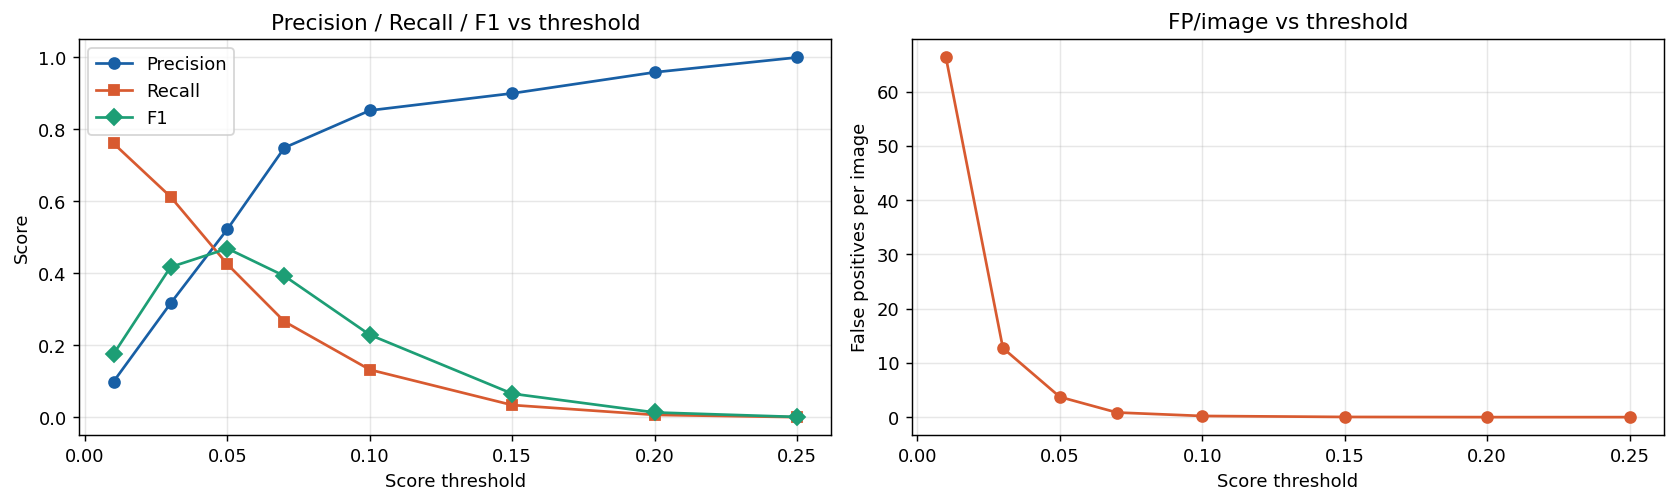

### 3. Per-class best threshold

,class,best_threshold,TP,FP,FN,precision,recall,F1
3,Dental implant,0.03,161,12,7,0.9306,0.9583,0.9443
9,Wisdom tooth,0.01,2765,430,91,0.8654,0.9681,0.9139
5,Maxillary sinus,0.07,54,8,6,0.8710,0.9000,0.8852
4,Mandibular nerve,0.10,66,9,9,0.8800,0.8800,0.8800
1,Dental crown,0.05,1070,167,140,0.8650,0.8843,0.8745
2,Dental filling,0.03,3118,816,1923,0.7926,0.6185,0.6948
7,Root canal traitement,0.07,387,649,1595,0.3736,0.1953,0.2565
8,Tooth decay,0.05,182,603,939,0.2318,0.1624,0.1910
0,Bone level resorption,0.03,65,516,335,0.1119,0.1625,0.1325
6,Periodental infection,0.03,61,509,494,0.1070,0.1099,0.1084


### 4. Weak-class error taxonomy

,class,total_GTs,true_positives,low_conf_TPs,localization_err,classification_err,missed_GTs,background_FPs
0,Bone level resorption,400,25,220,72,3,80,139
1,Periodental infection,555,19,221,178,4,133,12
2,Root canal traitement,1982,524,558,818,3,79,3281
3,Tooth decay,1121,160,431,410,3,117,324


### 5. Model comparison

,model,status,bbox_mAP,bbox_mAP50,mask_mAP,mask_mAP50,params,notes
0,YOLO-seg (Ultralytics baseline),REPORTED by Ultralytics — not re-evaluated in this pipeline,0.500,0.731,0.388,0.696,~23M,"Ultralytics internal eval, different preprocessing"
1,"A4 plain (this run, final)",FULLY EVALUATED in this notebook,0.309,0.562,0.118,0.347,128M,Best F1 = 0.469 at threshold 0.05
2,A5 (DINOv2 + RT-DETR + LoRA),"PRELIMINARY — evaluated in earlier run, not same exact pipeline",0.274,0.392,0.027,0.098,128M (~0.1M trainable in backbone),LoRA restricts backbone adaptation → weaker than A4 plain


**Extended analysis complete.** All CSVs saved to ANALYSIS_DIR.

In [33]:
# ── Display the extended analysis results inline ──
from IPython.display import display, Markdown

display(Markdown('## Extended analysis — summary'))

display(Markdown('### 1. BBox vs Mask AP summary'))
display(summary_df.round(4))

display(Markdown('### 2. Threshold sweep'))
display(sweep_df.round(4))
display(IPyImage(filename=str(ANALYSIS_DIR / 'threshold_sweep.png')))

display(Markdown('### 3. Per-class best threshold'))
display(per_class_best_df.round(4))

display(Markdown('### 4. Weak-class error taxonomy'))
display(error_df)

display(Markdown('### 5. Model comparison'))
display(comparison_df)

display(Markdown('**Extended analysis complete.** All CSVs saved to ANALYSIS_DIR.'))
